# DSAIT4335 Recommender Systems
# Final Project

In this project, you will work to build different recommendation models and evaluate the effectiveness of these models through offline experiments. The dataset used for the experiments is **MovieLens100K**, a movie recommendation dataset collected by GroupLens: https://grouplens.org/datasets/movielens/100k/. For more details, check the project description on Brightspace.

# Instruction

The MovieLens100K is already splitted into 80% training and 20% test sets. Along with training and test sets, movies metadata as content information is also provided.

**Expected file structure** for this assignment:   
   
   ```
   RecSysProject/
   ├── training.txt
   ├── test.txt
   ├── movies.txt
   └── codes.ipynb
   ```

**Note:** Be sure to run all cells in each section sequentially, so that intermediate variables and packages are properly carried over to subsequent cells.

**Note** Be sure to run all cells such that the submitted file contains the output of each cell.

**Note** Feel free to add cells if you need more for answering a question.

**Submission:** Answer all the questions in this jupyter-notebook file. Submit this jupyter-notebook file (your answers included) to Brightspace. Change the name of this jupyter-notebook file to your group number: example, group10 -> 10.ipynb.

# Setup

In [179]:
!pip install transformers torch  # For BERT
# you can refer https://huggingface.co/docs/transformers/en/model_doc/bert for various versions of the pre-trained model BERT

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [180]:
# For BERT embeddings (install: pip install transformers torch)
print("Check the status of BERT installation:")

try:
    from transformers import AutoTokenizer, AutoModel
    import torch
    BERT_AVAILABLE = True
    print("BERT libraries loaded successfully!")
    device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
except ImportError:
    BERT_AVAILABLE = False
    print("BERT libraries not available. Install with: pip install transformers torch")

Check the status of BERT installation:
BERT libraries loaded successfully!
Using device: mps


In [ ]:
import os
import re
import math
import time
import random
import warnings
from itertools import product
from typing import List, Tuple, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from scipy.sparse import csr_matrix
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from IPython.display import display
import inspect

warnings.filterwarnings('ignore')
os.makedirs('preds', exist_ok=True)
np.random.seed(10)

print("Libraries imported successfully!")


Libraries imported successfully!


# Load dataset

In [191]:
columns_name=['user_id','item_id','rating','timestamp']
train_data = pd.read_csv('training.txt', sep='\t', names=columns_name)
test_data = pd.read_csv('test.txt', sep='\t', names=columns_name)
val_data = test_data.copy()
print(f'The training data:')
display(train_data[['user_id','item_id','rating']].head())
print(f'The shape of the training data: {train_data.shape}')
print('--------------------------------')
print(f'The test data:')
display(test_data[['user_id','item_id','rating']].head())
print(f'The shape of the test data: {test_data.shape}')

The training data:


,user_id,item_id,rating
0,1,1,5
1,1,2,3
2,1,3,4
3,1,4,3
4,1,5,3


The shape of the training data: (80000, 4)
--------------------------------
The test data:


,user_id,item_id,rating
0,1,6,5
1,1,10,3
2,1,12,5
3,1,14,5
4,1,17,3


The shape of the test data: (20000, 4)


In [228]:
movies = pd.read_csv('movies.txt',names=['item_id','title','genres','description'],sep='\t')
movies.head()

,item_id,title,genres,description
0,1,Toy Story (1995),"Animation, Children's, Comedy","A group of sentient toys, who pretend to be li..."
1,2,GoldenEye (1995),"Action, Adventure, Thriller","In 1986, MI6 agents James Bond and Alec Trevel..."
2,3,Four Rooms (1995),Thriller,"On New Year's Eve, bellhop Sam (Marc Lawrence)..."
3,4,Get Shorty (1995),"Action, Comedy, Drama",Chili Palmer is a Miami-based loan shark and m...
4,5,Copycat (1995),"Crime, Drama, Thriller",After giving a guest lecture on criminal psych...


## Task 0) Utilities

### Save Predictions

In [184]:
def save_predictions_to_csv(
    model,
    test_data: pd.DataFrame,
    output_filepath: str,
    model_name: str = "Model") -> pd.DataFrame:
    """
    Generate predictions for test data and save to CSV.
    """
    print(f"Generating predictions using {model_name}...")
    
    predictions_list = []
    
    for _, row in tqdm(test_data[['user_id', 'item_id', 'rating']].iterrows(), 
                       total=len(test_data), 
                       desc=f"{model_name} Predictions"):
        user_id = row['user_id']
        item_id = row['item_id']
        actual_rating = row['rating']
        
        predicted_rating = model.predict_rating(user_id, item_id)
        predicted_rating = float(np.clip(predicted_rating, 1.0, 5.0))
        
        predictions_list.append({
            'user_id': user_id,
            'item_id': item_id,
            'actual_rating': float(actual_rating),
            'predicted_rating': predicted_rating
        })
    
    predictions_df = pd.DataFrame(predictions_list)
    
    rmse = np.sqrt(mean_squared_error(predictions_df['actual_rating'], 
                                       predictions_df['predicted_rating']))
    mae = mean_absolute_error(predictions_df['actual_rating'], 
                               predictions_df['predicted_rating'])
    
    predictions_df.to_csv(output_filepath, index=False)
    
    print(f"\nPredictions saved to: {output_filepath}")
    print(f"Results for {model_name}:")
    print(f"   - Total predictions: {len(predictions_df)}")
    print(f"   - RMSE: {rmse:.4f}")
    print(f"   - MAE: {mae:.4f}")

    return predictions_df

### Calculate Metrics

In [209]:
def evaluate_rmse(model, test_data: pd.DataFrame) -> float:
    preds = []
    trues = []
    
    for _, row in tqdm(test_data[['user_id', 'item_id', 'rating']].iterrows(), total=len(test_data)):
        u = row['user_id']
        i = row['item_id']
        true_r = row['rating']
        
        pred = model.predict_rating(u, i)
        
        preds.append(float(pred))
        trues.append(float(true_r))
    
    return float(math.sqrt(mean_squared_error(trues, preds)))


def evaluate_ranking_metrics(
    model,
    test_data: pd.DataFrame,
    train_data: pd.DataFrame,
    n: int = 10,
    relevance_threshold: float = 3.0
) -> Dict[str, float]:
    """
    Fast version of evaluate_ranking_metrics:
      - Vectorized DCG/NDCG
      - Precomputes denominators
      - Minimizes Python loops
    """
    test_users = test_data['user_id'].unique()

    # Build ground-truth per user (item -> rating)
    test_group = {
        uid: grp.set_index('item_id')['rating'].to_dict()
        for uid, grp in test_data.groupby('user_id')
    }

    # Precompute discount factors for DCG@k
    discounts = 1.0 / np.log2(np.arange(2, n + 2))

    precision_vals, recall_vals, ndcg_vals = [], [], []

    for user_id in tqdm(test_users, desc=f"Fast eval@{n}"):
        gt_dict = test_group.get(user_id)
        if not gt_dict:
            continue

        relevant_items = {i for i, r in gt_dict.items() if r >= relevance_threshold}
        if not relevant_items:
            continue

        try:
            recs = model.recommend_topk(user_id, n=n)
        except Exception:
            continue

        if not recs:
            continue

        rec_items = [i for i, _ in recs[:n]]
        rels = np.array([gt_dict.get(i, 0.0) for i in rec_items], dtype=float)

        # Precision / Recall
        rel_hits = np.sum(np.array([i in relevant_items for i in rec_items], dtype=bool))
        precision = rel_hits / n
        recall = rel_hits / len(relevant_items)
        precision_vals.append(precision)
        recall_vals.append(recall)

        # NDCG
        if np.any(rels):
            dcg = np.sum((2.0**rels - 1.0) * discounts)
            ideal_rels = np.sort(list(gt_dict.values()))[::-1][:n]
            idcg = np.sum((2.0**ideal_rels - 1.0) * discounts[: len(ideal_rels)])
            if idcg > 0:
                ndcg_vals.append(dcg / idcg)

    results = {
        f'precision@{n}': float(np.mean(precision_vals)) if precision_vals else 0.0,
        f'recall@{n}': float(np.mean(recall_vals)) if recall_vals else 0.0,
        f'ndcg@{n}': float(np.mean(ndcg_vals)) if ndcg_vals else 0.0,
        'num_users_evaluated': len(ndcg_vals)
    }

    return results

### Hyperparameters Sweep

In [186]:
def hyperparameter_sweep(
    model_class,
    train_data: pd.DataFrame,
    val_data: pd.DataFrame,
    param_grid: dict,
    metric: str = 'rmse'
) -> Tuple[dict, float, dict]:
    print(f"\nHyperparameter Sweep for {model_class.__name__} | Metric: {metric.upper()}")
    
    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())
    results = {}
    
    ranking_metrics = ['ndcg', 'precision', 'recall', 'f1']
    is_ranking = metric.lower() in ranking_metrics
    
    for param_combo in product(*param_values):
        params = dict(zip(param_names, param_combo))
        print(f"Testing {params}")
        
        model = model_class(**params)
        fit_signature = inspect.signature(model.fit)
        if 'val_data' in fit_signature.parameters:
            model.fit(train_data, val_data)
        else:
            model.fit(train_data)
        
        measure_set_size = val_data.shape[0]
        
        if metric == 'rmse':
            score_val = evaluate_rmse(model, val_data)
            score_train = evaluate_rmse(model, train_data[:measure_set_size])
            print(f"RMSE: val={score_val:.4f}, train={score_train:.4f}")
            results[str(params)] = {'params': params, metric: score_val}
        elif is_ranking:
            ranking_results = evaluate_ranking_metrics(model, val_data, train_data, n=10)
            p, r = ranking_results['precision@10'], ranking_results['recall@10']
            f1 = 2 * (p * r) / (p + r + 1e-10)
            ranking_results['f1@10'] = f1
            
            score_val = ranking_results.get(f'{metric}@10', f1 if metric == 'f1' else 0)
            results[str(params)] = {
                'params': params,
                'ndcg': ranking_results['ndcg@10'],
                'precision': p,
                'recall': r,
                'f1': f1,
                'num_users': ranking_results['num_users_evaluated']
            }
            print(f"Validation {metric.upper()}@10 = {score_val:.4f}")
        else:
            raise ValueError(f"Unknown metric: {metric}")
    
    if metric == 'rmse':
        best_key = min(results.keys(), key=lambda k: results[k]['rmse'])
        best_score = results[best_key]['rmse']
    else:
        best_key = max(results.keys(), key=lambda k: results[k][metric])
        best_score = results[best_key][metric]
    
    best_params = results[best_key]['params']
    print(f"\nBest params: {best_params} | Best {metric.upper()}: {best_score:.4f}\n")
    
    return best_params, best_score, results


def train_and_predict_best(
    model_class,
    train_data: pd.DataFrame,
    val_data: pd.DataFrame,
    test_data: pd.DataFrame,
    param_grid: dict,
    output_filepath: str,
    metric: str = 'rmse',
    model_name: Optional[str] = None
) -> Tuple[object, pd.DataFrame]:
    best_params, best_score, _ = hyperparameter_sweep(
        model_class, train_data, val_data, param_grid, metric
    )
    
    if model_name is None:
        model_name = model_class.__name__
    
    print(f"Training final model with best params: {best_params}")
    
    final_model = model_class(**best_params)
    fit_signature = inspect.signature(final_model.fit)
    if 'val_data' in fit_signature.parameters:
        final_model.fit(train_data, val_data)
    else:
        final_model.fit(train_data)
    
    predictions_df = save_predictions_to_csv(
        model=final_model,
        test_data=test_data,
        output_filepath=output_filepath,
        model_name=f"{model_name} {best_params}"
    )
    
    print(f"Done. Best {metric.upper()}: {best_score:.4f} | Saved to: {output_filepath}")
    return final_model, predictions_df


# Task 1) + Task 2) 
# Implementation of different recommendation models as well as a hybrid model combining those recommendation models
# Experiments for both rating prediction and ranking tasks, and conducting offline evaluation

### Content-based model

In [187]:
class ContentBasedCF:
    
    def __init__(self,
                 tfidf_max_features: int = 20000,
                 svd_dim: int = None,
                 normalize_emb: bool = True,
                 text_source: str = "full_text",
                 profile_agg: str = "weighted_avg",
                 positive_threshold: float = 4.0):
        self.tfidf_max_features = tfidf_max_features
        self.svd_dim = svd_dim
        self.normalize_emb = normalize_emb
        self.text_source = text_source
        self.profile_agg = profile_agg
        self.positive_threshold = positive_threshold

        self.train_data = None
        self.items = None
        self.users = None

        self.global_mean = None
        self.item_means = None
        self.user_means = None

        self.movies_df = None
        self.item_to_idx = None
        self.idx_to_item = None
        self.item_embeddings = None

        self._user_profiles = {}

    def _prepare_movie_features(self, movies_df: pd.DataFrame) -> pd.DataFrame:
        df = movies_df.copy()
        df['title'] = df['title'].fillna('')
        df['genres'] = df['genres'].fillna('')
        df['description'] = df['description'].fillna('')
        df['titlegenres'] = (df['title'] + ' ' + df['genres']).str.lower()
        df['full_text'] = (df['titlegenres'] + ' ' + df['description']).str.lower()
        return df

    def _tokenizer(self, s: str) -> List[str]:
        return re.findall(r"\w+|\S", s)

    def _compute_item_embeddings(self, corpus: List[str]) -> np.ndarray:
        tfidf = TfidfVectorizer(
            tokenizer=self._tokenizer,
            lowercase=False,
            ngram_range=(1, 2),
            stop_words='english',
            max_features=self.tfidf_max_features
        )
        X = tfidf.fit_transform(corpus)
        if self.svd_dim is not None and 0 < self.svd_dim < X.shape[1]:
            svd = TruncatedSVD(n_components=self.svd_dim, random_state=42)
            X = svd.fit_transform(X)
        else:
            X = X.toarray()
        if self.normalize_emb:
            X = normalize(X)
        return X

    def fit(self, train_data: pd.DataFrame, movies_df: pd.DataFrame):
        self.train_data = train_data
        self.users = set(train_data['user_id'].unique())
        self.items = set(train_data['item_id'].unique())
        self.global_mean = float(train_data['rating'].mean())
        self.item_means = train_data.groupby('item_id')['rating'].mean().to_dict()
        self.user_means = train_data.groupby('user_id')['rating'].mean().to_dict()

        self.movies_df = self._prepare_movie_features(movies_df)

        if self.text_source not in {'description', 'titlegenres', 'full_text'}:
            raise ValueError(f"Unknown text_source={self.text_source}")
        text_col = self.text_source

        self.item_to_idx = {iid: idx for idx, iid in enumerate(self.movies_df['item_id'])}
        self.idx_to_item = {idx: iid for iid, idx in self.item_to_idx.items()}

        self.item_embeddings = self._compute_item_embeddings(self.movies_df[text_col].tolist())
        self._user_profiles.clear()
        return self

    def _build_user_profile(self, user_id: int):
        rows = self.train_data[self.train_data['user_id'] == user_id]
        if rows.empty:
            return None

        if self.profile_agg == 'avg_pos':
            rows = rows[rows['rating'] >= self.positive_threshold]
            if rows.empty:
                return None

        rows = rows[rows['item_id'].isin(self.item_to_idx.keys())]
        if rows.empty:
            return None

        idxs = [self.item_to_idx[i] for i in rows['item_id']]
        embs = self.item_embeddings[idxs]

        if self.profile_agg == 'weighted_avg':
            weights = rows['rating'].to_numpy(dtype=float)
            prof = np.average(embs, axis=0, weights=weights)
        else:
            prof = embs.mean(axis=0)

        prof = prof / (np.linalg.norm(prof) + 1e-9)
        return prof

    def _get_user_profile(self, user_id: int):
        if user_id in self._user_profiles:
            return self._user_profiles[user_id]
        prof = self._build_user_profile(user_id)
        if prof is not None:
            self._user_profiles[user_id] = prof
        return prof

    def predict_rating(self, user_id: int, item_id: int) -> float:
        if self.train_data is None or self.item_embeddings is None:
            return float(np.clip(self.global_mean if self.global_mean is not None else 3.0, 1.0, 5.0))

        user_known = user_id in self.user_means
        item_known = item_id in self.item_to_idx

        if not user_known and not item_known:
            return float(np.clip(self.global_mean, 1.0, 5.0))
        if not user_known and item_known:
            return float(np.clip(self.item_means.get(item_id, self.global_mean), 1.0, 5.0))
        if user_known and not item_known:
            return float(np.clip(self.user_means.get(user_id, self.global_mean), 1.0, 5.0))

        profile = self._get_user_profile(user_id)
        if profile is None:
            um = self.user_means.get(user_id, self.global_mean)
            im = self.item_means.get(item_id, np.nan)
            return float(np.clip(um if np.isnan(im) else (um + im) / 2, 1.0, 5.0))

        item_vec = self.item_embeddings[self.item_to_idx[item_id]]
        item_vec = item_vec / (np.linalg.norm(item_vec) + 1e-9)

        sim = float(np.dot(profile, item_vec))
        um = self.user_means.get(user_id, self.global_mean)
        pred = um + 2.0 * sim
        return float(np.clip(pred, 1.0, 5.0))

    def recommend_topk(self, target_user: int, n: int = 10) -> List[Tuple[int, float]]:
        if self.train_data is None or self.item_embeddings is None:
            return []
        if target_user not in self.users:
            avail = [(iid, self.item_means.get(iid, self.global_mean))
                     for iid in self.item_to_idx.keys()]
            return sorted(avail, key=lambda x: x[1], reverse=True)[:n]

        seen = set(self.train_data[self.train_data['user_id'] == target_user]['item_id'])
        candidates = [iid for iid in self.item_to_idx.keys() if iid not in seen]
        if not candidates:
            return []

        prof = self._get_user_profile(target_user)
        if prof is None:
            avail = [(iid, self.item_means.get(iid, self.global_mean)) for iid in candidates]
            return sorted(avail, key=lambda x: x[1], reverse=True)[:n]

        idxs = [self.item_to_idx[iid] for iid in candidates]
        cand = self.item_embeddings[idxs]
        cand = cand / (np.linalg.norm(cand, axis=1, keepdims=True) + 1e-9)
        sims = cand @ prof

        base = self.user_means.get(target_user, self.global_mean)
        scores = np.clip(base + 2.0 * sims, 1.0, 5.0)
        top = np.argsort(scores)[::-1][:n]
        return [(candidates[i], float(scores[i])) for i in top]


### Fit Content-based for Rating

In [224]:
param_grid = {
    'tfidf_max_features': [5000, 7500],
    'svd_dim': [256, None],
    'normalize_emb': [True],
    'text_source': ['titlegenres'],
    'profile_agg': ['avg'],
    'positive_threshold': [2.75, 3]
}

class ContentBasedCFWithMovies(ContentBasedCF):
    def __init__(self, movies_df, **kwargs):
        super().__init__(**kwargs)
        self._movies_df_external = movies_df
    
    def fit(self, train_data: pd.DataFrame):
        return super().fit(train_data, self._movies_df_external)

content_model_best, content_predictions = train_and_predict_best(
    model_class=lambda **kw: ContentBasedCFWithMovies(movies_df=movies, **kw),
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    param_grid=param_grid,
    output_filepath='preds/predictions_content_best.csv',
    metric='rmse'
)


Hyperparameter Sweep for <lambda> | Metric: RMSE
Testing {'tfidf_max_features': 5000, 'svd_dim': 256, 'normalize_emb': True, 'text_source': 'titlegenres', 'profile_agg': 'avg', 'positive_threshold': 2.75}


100%|██████████| 20000/20000 [00:00<00:00, 49172.68it/s]


RMSE: val=1.3034, train=1.2975
Testing {'tfidf_max_features': 5000, 'svd_dim': 256, 'normalize_emb': True, 'text_source': 'titlegenres', 'profile_agg': 'avg', 'positive_threshold': 3}


100%|██████████| 20000/20000 [00:00<00:00, 48883.38it/s]


RMSE: val=1.3034, train=1.2975
Testing {'tfidf_max_features': 5000, 'svd_dim': None, 'normalize_emb': True, 'text_source': 'titlegenres', 'profile_agg': 'avg', 'positive_threshold': 2.75}


...

RMSE: val=1.1762, train=1.1832
Testing {'tfidf_max_features': 7500, 'svd_dim': None, 'normalize_emb': True, 'text_source': 'titlegenres', 'profile_agg': 'avg', 'positive_threshold': 3}


100%|██████████| 20000/20000 [00:00<00:00, 40558.08it/s]


RMSE: val=1.1762, train=1.1832

Best params: {'tfidf_max_features': 7500, 'svd_dim': None, 'normalize_emb': True, 'text_source': 'titlegenres', 'profile_agg': 'avg', 'positive_threshold': 2.75} | Best RMSE: 1.1762

Training final model with best params: {'tfidf_max_features': 7500, 'svd_dim': None, 'normalize_emb': True, 'text_source': 'titlegenres', 'profile_agg': 'avg', 'positive_threshold': 2.75}
Generating predictions using <lambda> {'tfidf_max_features': 7500, 'svd_dim': None, 'normalize_emb': True, 'text_source': 'titlegenres', 'profile_agg': 'avg', 'positive_threshold': 2.75}...


<lambda> {'tfidf_max_features': 7500, 'svd_dim': None, 'normalize_emb': True, 'text_source': 'titlegenres', 'profile_agg': 'avg', 'positive_threshold': 2.75} Predictions: 100%|██████████| 20000/20000 [00:00<00:00, 23352.18it/s]


Predictions saved to: preds/predictions_content_best.csv
Results for <lambda> {'tfidf_max_features': 7500, 'svd_dim': None, 'normalize_emb': True, 'text_source': 'titlegenres', 'profile_agg': 'avg', 'positive_threshold': 2.75}:
   - Total predictions: 20000
   - RMSE: 1.1762
   - MAE: 0.9111
Done. Best RMSE: 1.1762 | Saved to: preds/predictions_content_best.csv


### Fit Content-based for Ranking

In [225]:
content_ndcg_model, content_ndcg_predictions = train_and_predict_best(
    model_class=lambda **kw: ContentBasedCFWithMovies(movies_df=movies, **kw),
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    param_grid={
        'tfidf_max_features': [7500, 10000],
        'svd_dim': [1024, None],
        'normalize_emb': [True],
        'text_source': ['titlegenres'],
        'profile_agg': ['avg'],
        'positive_threshold': [2]
    },
    output_filepath='preds/predictions_content_ndcg.csv',
    metric='ndcg',
    model_name='Content-Based CF (NDCG-optimized)'
)

content_ndcg_ranking_metrics = evaluate_ranking_metrics(
    model=content_ndcg_model,
    test_data=test_data,
    train_data=train_data,
    n=10,
    relevance_threshold=2.0
)

print(f"\nRanking Performance (NDCG-optimized):")
print(f"  Precision@10: {content_ndcg_ranking_metrics['precision@10']:.4f}")
print(f"  Recall@10:    {content_ndcg_ranking_metrics['recall@10']:.4f}")
print(f"  NDCG@10:      {content_ndcg_ranking_metrics['ndcg@10']:.4f}")



Hyperparameter Sweep for <lambda> | Metric: NDCG
Testing {'tfidf_max_features': 7500, 'svd_dim': 1024, 'normalize_emb': True, 'text_source': 'titlegenres', 'profile_agg': 'avg', 'positive_threshold': 2}


Fast eval@10: 100%|██████████| 459/459 [00:02<00:00, 158.80it/s]


Validation NDCG@10 = 0.0955
Testing {'tfidf_max_features': 7500, 'svd_dim': None, 'normalize_emb': True, 'text_source': 'titlegenres', 'profile_agg': 'avg', 'positive_threshold': 2}


Fast eval@10: 100%|██████████| 459/459 [00:12<00:00, 36.15it/s]


Validation NDCG@10 = 0.0857
Testing {'tfidf_max_features': 10000, 'svd_dim': 1024, 'normalize_emb': True, 'text_source': 'titlegenres', 'profile_agg': 'avg', 'positive_threshold': 2}


...

Validation NDCG@10 = 0.0857

Best params: {'tfidf_max_features': 7500, 'svd_dim': 1024, 'normalize_emb': True, 'text_source': 'titlegenres', 'profile_agg': 'avg', 'positive_threshold': 2} | Best NDCG: 0.0955

Training final model with best params: {'tfidf_max_features': 7500, 'svd_dim': 1024, 'normalize_emb': True, 'text_source': 'titlegenres', 'profile_agg': 'avg', 'positive_threshold': 2}
Generating predictions using Content-Based CF (NDCG-optimized) {'tfidf_max_features': 7500, 'svd_dim': 1024, 'normalize_emb': True, 'text_source': 'titlegenres', 'profile_agg': 'avg', 'positive_threshold': 2}...


Content-Based CF (NDCG-optimized) {'tfidf_max_features': 7500, 'svd_dim': 1024, 'normalize_emb': True, 'text_source': 'titlegenres', 'profile_agg': 'avg', 'positive_threshold': 2} Predictions: 100%|██████████| 20000/20000 [00:00<00:00, 25756.80it/s]



Predictions saved to: preds/predictions_content_ndcg.csv
Results for Content-Based CF (NDCG-optimized) {'tfidf_max_features': 7500, 'svd_dim': 1024, 'normalize_emb': True, 'text_source': 'titlegenres', 'profile_agg': 'avg', 'positive_threshold': 2}:
   - Total predictions: 20000
   - RMSE: 1.2099
   - MAE: 0.9350
Done. Best NDCG: 0.0955 | Saved to: preds/predictions_content_ndcg.csv


Fast eval@10: 100%|██████████| 459/459 [00:02<00:00, 164.30it/s]


Ranking Performance (NDCG-optimized):
  Precision@10: 0.1046
  Recall@10:    0.0386
  NDCG@10:      0.0955


### User-based (UserKNN)

In [243]:
class UserBasedCF:
    def __init__(self, k: int = 50, min_common: int = 2, use_pearson: bool = True):
        self.k = k
        self.min_common = min_common
        self.use_pearson = use_pearson
        self.train_data = None
        self.users = None
        self.items = None
        self.global_mean = None
        self.user_means = None
        self.item_means = None
        self.user_to_index = {}
        self.item_to_index = {}
        self.index_to_user = {}
        self.index_to_item = {}
        self.user_item_matrix = None
        self.user_similarity_matrix = None
        self.user_neighbors = {}
        self.all_predictions = None

    def _build_matrix(self, df: pd.DataFrame) -> csr_matrix:
        users = df["user_id"].unique()
        items = df["item_id"].unique()
        self.users, self.items = users, items
        self.user_to_index = {u: i for i, u in enumerate(users)}
        self.item_to_index = {it: j for j, it in enumerate(items)}
        self.index_to_user = {i: u for u, i in self.user_to_index.items()}
        self.index_to_item = {j: it for it, j in self.item_to_index.items()}
        rows = df["user_id"].map(self.user_to_index).to_numpy()
        cols = df["item_id"].map(self.item_to_index).to_numpy()
        vals = df["rating"].astype(float).to_numpy()
        return csr_matrix((vals, (rows, cols)), shape=(len(users), len(items)))

    def compute_user_similarity_matrix(self, R: csr_matrix) -> np.ndarray:
        X = R.toarray().astype(float)
        if self.use_pearson:
            mask = (X != 0)
            sums = X.sum(axis=1)
            counts = mask.sum(axis=1)
            means = np.divide(sums, counts, out=np.zeros_like(sums), where=counts != 0)
            X = np.where(mask, X - means[:, np.newaxis], 0.0)
        sims = cosine_similarity(X)
        np.fill_diagonal(sims, 1.0)
        return sims

    def build_topk_neighbors(self, sim_matrix: np.ndarray, k: int) -> Dict[int, List[Tuple[int, float]]]:
        topk = {}
        n_users = sim_matrix.shape[0]
        for u in range(n_users):
            sims = sim_matrix[u]
            top_idx = np.argpartition(-sims, range(1, k + 1))[1:k + 1]
            sorted_idx = top_idx[np.argsort(-sims[top_idx])]
            topk[self.index_to_user[u]] = [(self.index_to_user[i], float(sims[i])) for i in sorted_idx if sims[i] > 0]
        return topk

    def fit(self, train_data: pd.DataFrame):
        self.train_data = train_data
        self.global_mean = float(train_data["rating"].mean())
        self.user_means = train_data.groupby("user_id")["rating"].mean().to_dict()
        self.item_means = train_data.groupby("item_id")["rating"].mean().to_dict()
        self.user_item_matrix = self._build_matrix(train_data)
        self.user_similarity_matrix = self.compute_user_similarity_matrix(self.user_item_matrix)
        self.user_neighbors = self.build_topk_neighbors(self.user_similarity_matrix, self.k)
        self._precompute_all_predictions()
        return self

    def _precompute_all_predictions(self):
        R = self.user_item_matrix.toarray().astype(float)
        M = (R != 0).astype(float)
        sims = self.user_similarity_matrix.copy()
        sums = R.sum(axis=1)
        counts = M.sum(axis=1)
        user_means = np.divide(sums, counts, out=np.zeros_like(sums), where=counts > 0)
        n_users, n_items = R.shape
        preds = np.zeros((n_users, n_items), dtype=float)

        for u in range(n_users):
            sim_row = sims[u].copy()
            sim_row[u] = 0.0
            pos_mask = (sim_row > 0)
            if not np.any(pos_mask):
                preds[u, :] = user_means[u]
                continue
            pos_idx = np.where(pos_mask)[0]
            k_eff = min(self.k, pos_idx.size)
            top_idx = pos_idx[np.argpartition(-sim_row[pos_idx], k_eff - 1)[:k_eff]]
            w = sim_row[top_idx][:, None]
            R_top = R[top_idx, :]
            M_top = M[top_idx, :]
            mu_top = user_means[top_idx][:, None]
            centered = (R_top - mu_top) * M_top
            num = (w * centered).sum(axis=0)
            den = (np.abs(w) * M_top).sum(axis=0)
            den = np.where(den > 0, den, 1e-8)
            preds[u, :] = user_means[u] + num / den

        self.all_predictions = np.clip(preds, 1.0, 5.0)

    def predict_rating(self, user_id: int, item_id: int) -> float:
        if (user_id not in self.user_to_index) or (item_id not in self.item_to_index):
            return float(self.global_mean)
        u = self.user_to_index[user_id]
        i = self.item_to_index[item_id]
        return float(self.all_predictions[u, i])

    def recommend_topk(self, target_user: int, n: int = 10) -> List[Tuple[int, float]]:
        if target_user not in self.user_to_index:
            return sorted(self.item_means.items(), key=lambda x: x[1], reverse=True)[:n]
        u_idx = self.user_to_index[target_user]
        preds = self.all_predictions[u_idx].copy()
        seen_items = self.train_data.loc[self.train_data["user_id"] == target_user, "item_id"]
        seen_indices = seen_items.map(self.item_to_index).dropna().astype(int).to_numpy()
        preds[seen_indices] = -np.inf
        n_items = min(n, len(preds))
        if n_items == 0:
            return []
        top_idx = np.argpartition(-preds, n_items - 1)[:n_items]
        sorted_idx = top_idx[np.argsort(-preds[top_idx])]
        return [(self.index_to_item[i], float(preds[i])) for i in sorted_idx]


def train_user_based_cf(train_data: pd.DataFrame, k: int = 50, min_common: int = 2) -> UserBasedCF:
    model = UserBasedCF(k=k, min_common=min_common)
    model.fit(train_data)
    return model


### Fit UserKNN for Rating

In [ ]:
user_knn_model, user_knn_predictions = train_and_predict_best(
    model_class=UserBasedCF,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    param_grid={'k': [100, 200], 'min_common': [10]},
    output_filepath='preds/predictions_userknn_best.csv',
    metric='rmse'
)


Hyperparameter Sweep for UserBasedCF
Testing parameters: {'k': [100, 200], 'min_common': [10]}
Optimization metric: RMSE


Testing: {'k': 100, 'min_common': 10}

Dataset statistics:
  Users: 943
  Items: 1650
  Ratings: 80000
  Density: 5.142%


100%|██████████| 4000/4000 [00:51<00:00, 77.95it/s]


RMSE (Validation) = 0.9754


100%|██████████| 4000/4000 [00:51<00:00, 78.31it/s] 


RMSE (Training) = 0.8261

Testing: {'k': 200, 'min_common': 10}

Dataset statistics:
  Users: 943
  Items: 1650
  Ratings: 80000
  Density: 5.142%


...

RMSE (Training) = 0.8464

Best parameters: {'k': 200, 'min_common': 10}
Best RMSE: 0.9609


Training final model with best parameters
Parameters: {'k': 200, 'min_common': 10}


Dataset statistics:
  Users: 943
  Items: 1650
  Ratings: 80000
  Density: 5.142%


Computing user-user similarities (min_common=10): 100%|██████████| 943/943 [07:40<00:00,  2.05it/s]  


Generating predictions using UserBasedCF {'k': 200, 'min_common': 10}...


UserBasedCF {'k': 200, 'min_common': 10} Predictions: 100%|██████████| 16000/16000 [46:22<00:00,  5.75it/s]   


Predictions saved to: preds/predictions_userknn_best.csv
Results for UserBasedCF {'k': 200, 'min_common': 10}:
   - Total predictions: 16000
   - RMSE: 0.9675
   - MAE: 0.7564

Summary:
  - Best parameters: {'k': 200, 'min_common': 10}
  - Best RMSE: 0.9609
  - Predictions saved to: preds/predictions_userknn_best.csv



### Fit UserKNN for Ranking

In [244]:
user_knn_ndcg_model, user_knn_ndcg_predictions = train_and_predict_best(
    model_class=UserBasedCF,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    param_grid={
        'k': [150, 250],
        'min_common': [2, 4]
    },
    output_filepath='preds/predictions_userknn_ndcg.csv',
    metric='ndcg',
    model_name='User-Based CF (NDCG-optimized)'
)


Hyperparameter Sweep for UserBasedCF | Metric: NDCG
Testing {'k': 150, 'min_common': 2}


Fast eval@10: 100%|██████████| 459/459 [00:00<00:00, 1336.95it/s]


Validation NDCG@10 = 0.1041
Testing {'k': 150, 'min_common': 4}


Fast eval@10: 100%|██████████| 459/459 [00:00<00:00, 1353.00it/s]


Validation NDCG@10 = 0.1041
Testing {'k': 250, 'min_common': 2}


...

Validation NDCG@10 = 0.1036
Testing {'k': 250, 'min_common': 4}


Fast eval@10: 100%|██████████| 459/459 [00:00<00:00, 1322.17it/s]


Validation NDCG@10 = 0.1036

Best params: {'k': 150, 'min_common': 2} | Best NDCG: 0.1041

Training final model with best params: {'k': 150, 'min_common': 2}
Generating predictions using User-Based CF (NDCG-optimized) {'k': 150, 'min_common': 2}...


User-Based CF (NDCG-optimized) {'k': 150, 'min_common': 2} Predictions: 100%|██████████| 20000/20000 [00:00<00:00, 66534.01it/s]


Predictions saved to: preds/predictions_userknn_ndcg.csv
Results for User-Based CF (NDCG-optimized) {'k': 150, 'min_common': 2}:
   - Total predictions: 20000
   - RMSE: 0.9579
   - MAE: 0.7474
Done. Best NDCG: 0.1041 | Saved to: preds/predictions_userknn_ndcg.csv


### Item-based (ItemKNN)

In [ ]:
class ItemBasedCF:
    def __init__(self, k: int = 50, min_common: int = 2):
        self.k = k
        self.min_common = min_common
        self.train_data = None
        self.item_similarity_matrix = None
        self.users = None
        self.items = None
        self.user_means = None
        self.global_mean = None
        self.item_means = None

        self._user_ids = None
        self._item_ids = None
        self._user_index = None
        self._item_index = None
        self._R = None

    def _build_sparse_matrix(self, train_data: pd.DataFrame) -> csr_matrix:
        self._user_ids = train_data['user_id'].unique()
        self._item_ids = train_data['item_id'].unique()
        self._user_index = {u: i for i, u in enumerate(self._user_ids)}
        self._item_index = {it: j for j, it in enumerate(self._item_ids)}

        rows = train_data['user_id'].map(self._user_index).to_numpy()
        cols = train_data['item_id'].map(self._item_index).to_numpy()
        vals = train_data['rating'].astype(float).fillna(0.0).to_numpy()

        R = csr_matrix((vals, (rows, cols)), shape=(len(self._user_ids), len(self._item_ids)))
        return R

    def compute_item_similarity_matrix(self, train_data: pd.DataFrame) -> pd.DataFrame:
        self._R = self._build_sparse_matrix(train_data)
        sims = cosine_similarity(self._R.T, dense_output=False)
        item_similarity_matrix = pd.DataFrame(
            sims.toarray(), index=self._item_ids, columns=self._item_ids
        )
        np.fill_diagonal(item_similarity_matrix.values, 1.0)
        return item_similarity_matrix

    def get_k_item_neighbors(self, target_item: int, k: int = None) -> List[Tuple[int, float]]:
        if k is None:
            k = self.k
        if self.item_similarity_matrix is None or target_item not in self.item_similarity_matrix.index:
            return []
        
        sims = self.item_similarity_matrix.loc[target_item].drop(labels=target_item, errors='ignore')
        sims = sims[sims > 0]
        
        top_series = sims.sort_values(ascending=False).head(k)
        return list(top_series.items())

    def predict_rating(self, target_user: int, target_item: int) -> float:
        if self.item_similarity_matrix is None or self.train_data is None:
            return float(self.global_mean)

        if target_item not in self.item_similarity_matrix.index:
            return float(self.item_means.get(target_item, self.global_mean))

        user_ratings = self.train_data[self.train_data['user_id'] == target_user]
        if user_ratings.empty:
            return float(self.item_means.get(target_item, self.global_mean))

        user_ratings = user_ratings.set_index('item_id')['rating']

        sims = self.item_similarity_matrix.loc[target_item].drop(labels=target_item, errors='ignore')
        common_items = user_ratings.index.intersection(sims.index)
        
        if len(common_items) == 0:
            return float(self.item_means.get(target_item, self.global_mean))

        sims_common = sims.loc[common_items].dropna()
        
        if len(sims_common) < self.min_common:
            return float(self.item_means.get(target_item, self.global_mean))

        if sims_common.empty:
            return float(self.item_means.get(target_item, self.global_mean))

        top_sims = sims_common.sort_values(ascending=False).head(self.k)
        r_u = user_ratings.reindex(top_sims.index).astype(float)
        s = top_sims.reindex(r_u.index)
        
        mask = r_u.notna() & s.notna()
        if mask.sum() == 0:
            return float(self.item_means.get(target_item, self.global_mean))

        num = (s[mask] * r_u[mask]).sum()
        den = s[mask].abs().sum()

        if den == 0.0 or np.isnan(den):
            return float(self.item_means.get(target_item, self.global_mean))

        result = float(num / den)
        
        if np.isnan(result) or np.isinf(result):
            return float(self.item_means.get(target_item, self.global_mean))

        return float(np.clip(result, 1.0, 5.0))

    def recommend_topk(self, target_user: int, n: int = 10) -> List[Tuple[int, float]]:
        if self.train_data is None or self.item_similarity_matrix is None:
            return []
        
        if target_user not in self.train_data['user_id'].unique():
            popular_items = sorted(self.item_means.items(), key=lambda x: x[1], reverse=True)[:n]
            return popular_items 

        seen_items = set(self.train_data.loc[self.train_data['user_id'] == target_user, 'item_id'].unique())
        candidate_items = self.items - seen_items

        scores = []
        for item in candidate_items:
            pred = self.predict_rating(target_user, item)
            scores.append((item, float(pred)))
        
        scores.sort(key=lambda x: x[1], reverse=True)
        return scores[:n]

    def fit(self, train_data: pd.DataFrame):
        self.train_data = train_data
        self.users = set(train_data['user_id'].unique())
        self.items = set(train_data['item_id'].unique())
        self.global_mean = float(train_data['rating'].mean())
        self.user_means = train_data.groupby('user_id')['rating'].mean().to_dict()
        self.item_means = train_data.groupby('item_id')['rating'].mean().to_dict()

        self.item_similarity_matrix = self.compute_item_similarity_matrix(train_data)
        return self


### Fit ItemKNN for Rating

In [ ]:
item_knn_model, item_knn_predictions = train_and_predict_best(
    model_class=ItemBasedCF,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    param_grid={
        'k': [30, 50, 70],
        'min_common': [2, 5]
    },
    output_filepath='preds/predictions_itemknn_best.csv',
    metric='rmse'
)


Hyperparameter Sweep for ItemBasedCF
Testing parameters: {'k': [30, 50, 70], 'min_common': [2, 5]}
Optimization metric: RMSE


Testing: {'k': 30, 'min_common': 2}

Dataset statistics:
  Users: 943
  Items: 1650
  Ratings: 80000
  Density: 5.14%
  min_common threshold: 2
Similarity matrix computed: (1650, 1650)


100%|██████████| 4000/4000 [00:02<00:00, 1388.21it/s]


RMSE (Validation) = 1.0004


100%|██████████| 4000/4000 [00:02<00:00, 1431.27it/s]


RMSE (Training) = 1.0336

Testing: {'k': 30, 'min_common': 5}

Dataset statistics:
  Users: 943
  Items: 1650
  Ratings: 80000
  Density: 5.14%
  min_common threshold: 5
Similarity matrix computed: (1650, 1650)


...

RMSE (Validation) = 1.0173


100%|██████████| 4000/4000 [00:02<00:00, 1405.83it/s]


RMSE (Training) = 1.0498

Best parameters: {'k': 30, 'min_common': 5}
Best RMSE: 1.0002


Training final model with best parameters
Parameters: {'k': 30, 'min_common': 5}


Dataset statistics:
  Users: 943
  Items: 1650
  Ratings: 80000
  Density: 5.14%
  min_common threshold: 5
Similarity matrix computed: (1650, 1650)
Generating predictions using ItemBasedCF {'k': 30, 'min_common': 5}...


ItemBasedCF {'k': 30, 'min_common': 5} Predictions: 100%|██████████| 16000/16000 [00:11<00:00, 1345.37it/s]


Predictions saved to: preds/predictions_itemknn_best.csv
Results for ItemBasedCF {'k': 30, 'min_common': 5}:
   - Total predictions: 16000
   - RMSE: 1.0064
   - MAE: 0.7863

Summary:
  - Best parameters: {'k': 30, 'min_common': 5}
  - Best RMSE: 1.0002
  - Predictions saved to: preds/predictions_itemknn_best.csv



### Fir ItemKNN for Ranking

In [226]:
print("\n" + "="*80)
print("ITEM-BASED CF: HYPERPARAMETER TUNING FOR NDCG@10")
print("="*80)

item_knn_ndcg_model, item_knn_ndcg_predictions = train_and_predict_best(
    model_class=ItemBasedCF,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    param_grid={
        'k': [60],
        'min_common': [2]
    },
    output_filepath='preds/predictions_itemknn_ndcg.csv',
    metric='ndcg',
    model_name='Item-Based CF (NDCG-optimized)'
)


print("\n" + "="*80)
print("EVALUATING NDCG-OPTIMIZED ITEM-BASED MODEL")
print("="*80)

item_knn_ndcg_ranking_metrics = evaluate_ranking_metrics(
    model=item_knn_ndcg_model,
    test_data=test_data,
    train_data=train_data,
    n=10,
    relevance_threshold=2.0
)

print(f"\nRanking Performance (NDCG-optimized):")
print(f"  Precision@10: {item_knn_ndcg_ranking_metrics['precision@10']:.4f}")
print(f"  Recall@10:    {item_knn_ndcg_ranking_metrics['recall@10']:.4f}")
print(f"  NDCG@10:      {item_knn_ndcg_ranking_metrics['ndcg@10']:.4f}")


ITEM-BASED CF: HYPERPARAMETER TUNING FOR NDCG@10

Hyperparameter Sweep for ItemBasedCF | Metric: NDCG
Testing {'k': 60, 'min_common': 2}

Dataset statistics:
  Users: 943
  Items: 1650
  Ratings: 80000
  Density: 5.14%
  min_common threshold: 2
Similarity matrix computed: (1650, 1650)


Fast eval@10: 100%|██████████| 459/459 [08:31<00:00,  1.12s/it]


Validation NDCG@10 = 0.1627

Best params: {'k': 60, 'min_common': 2} | Best NDCG: 0.1627

Training final model with best params: {'k': 60, 'min_common': 2}

Dataset statistics:
  Users: 943
  Items: 1650
  Ratings: 80000
  Density: 5.14%
  min_common threshold: 2
Similarity matrix computed: (1650, 1650)
Generating predictions using Item-Based CF (NDCG-optimized) {'k': 60, 'min_common': 2}...


Item-Based CF (NDCG-optimized) {'k': 60, 'min_common': 2} Predictions: 100%|██████████| 20000/20000 [00:15<00:00, 1299.43it/s]



Predictions saved to: preds/predictions_itemknn_ndcg.csv
Results for Item-Based CF (NDCG-optimized) {'k': 60, 'min_common': 2}:
   - Total predictions: 20000
   - RMSE: 1.0178
   - MAE: 0.8004
Done. Best NDCG: 0.1627 | Saved to: preds/predictions_itemknn_ndcg.csv

EVALUATING NDCG-OPTIMIZED ITEM-BASED MODEL


Fast eval@10: 100%|██████████| 459/459 [08:28<00:00,  1.11s/it]


Ranking Performance (NDCG-optimized):
  Precision@10: 0.0266
  Recall@10:    0.0030
  NDCG@10:      0.1627


### Matrix Factorization

In [ ]:
class RatingDataset(Dataset):
    
    def __init__(self, user_ids, item_ids, ratings):
        self.users = torch.LongTensor(user_ids)
        self.items = torch.LongTensor(item_ids)
        self.ratings = torch.FloatTensor(ratings)
    
    def __len__(self):
        return len(self.ratings)
    
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]


class MatrixFactorizationSGD:
    def __init__(self, n_factors, learning_rate, n_epochs, use_bias, eval_every, 
                 batch_size=1024, device='auto', l2_reg=0.01):
        self.n_factors = n_factors
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.use_bias = use_bias
        self.eval_every = eval_every
        self.batch_size = batch_size
        self.l2_reg = l2_reg
        
        if device == 'auto':
            self.device = torch.device('mps' if torch.backends.mps.is_available() 
                                      else 'cuda' if torch.cuda.is_available() 
                                      else 'cpu')
        else:
            self.device = torch.device(device)
        
        print(f"Device: {self.device}")
        
        self.P = None
        self.Q = None
        self.user_bias = None
        self.item_bias = None
        self.global_mean = None
        self.user_mapping = None
        self.item_mapping = None
        self.user_inv = None
        self.item_inv = None
        
        self.history = {
            'train_rmse': [],
            'val_rmse': [],
            'epochs': []
        }
        self.best_epoch = None
        self.best_val_rmse = float('inf')

    def _initialize_model(self, train_data: pd.DataFrame):
        self.user_mapping = {u: i for i, u in enumerate(train_data['user_id'].unique())}
        self.item_mapping = {i: j for j, i in enumerate(train_data['item_id'].unique())}
        self.user_inv = {i: u for u, i in self.user_mapping.items()}
        self.item_inv = {j: i for i, j in self.item_mapping.items()}

        n_users = len(self.user_mapping)
        n_items = len(self.item_mapping)

        self.P = nn.Embedding(n_users, self.n_factors).to(self.device)
        self.Q = nn.Embedding(n_items, self.n_factors).to(self.device)
        
        nn.init.normal_(self.P.weight, mean=0, std=0.01)
        nn.init.normal_(self.Q.weight, mean=0, std=0.01)

        if self.use_bias:
            self.user_bias = nn.Embedding(n_users, 1).to(self.device)
            self.item_bias = nn.Embedding(n_items, 1).to(self.device)
            nn.init.zeros_(self.user_bias.weight)
            nn.init.zeros_(self.item_bias.weight)
            self.global_mean = float(train_data['rating'].mean())

    def _prepare_training_data(self, train_data: pd.DataFrame):
        user_ids = [self.user_mapping[u] for u in train_data['user_id']]
        item_ids = [self.item_mapping[i] for i in train_data['item_id']]
        ratings = train_data['rating'].values
        
        return RatingDataset(user_ids, item_ids, ratings)

    def _train_one_epoch(self, dataloader, optimizer) -> float:
        self.P.train()
        self.Q.train()
        if self.use_bias:
            self.user_bias.train()
            self.item_bias.train()
        
        total_loss = 0.0
        n_batches = 0
        
        for users, items, ratings in dataloader:
            users = users.to(self.device)
            items = items.to(self.device)
            ratings = ratings.to(self.device)
            
            user_emb = self.P(users)
            item_emb = self.Q(items)
            
            preds = (user_emb * item_emb).sum(dim=1)
            
            if self.use_bias:
                preds = preds + self.global_mean
                preds = preds + self.user_bias(users).squeeze()
                preds = preds + self.item_bias(items).squeeze()
            
            mse_loss = nn.functional.mse_loss(preds, ratings)
            
            l2_loss = 0.0
            if self.l2_reg > 0:
                l2_loss = (
                    self.l2_reg * (user_emb.pow(2).sum() + item_emb.pow(2).sum())
                ) / users.size(0)
                
                if self.use_bias:
                    l2_loss += (
                        self.l2_reg * 0.1 * (
                            self.user_bias(users).pow(2).sum() + 
                            self.item_bias(items).pow(2).sum()
                        )
                    ) / users.size(0)
            
            loss = mse_loss + l2_loss
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += mse_loss.item()
            n_batches += 1
        
        return np.sqrt(total_loss / n_batches)

    def _should_evaluate(self, epoch: int) -> bool:
        return (epoch + 1) % self.eval_every == 0 or (epoch + 1) == self.n_epochs

    def _compute_rmse(self, data: pd.DataFrame) -> float:
        self.P.eval()
        self.Q.eval()
        if self.use_bias:
            self.user_bias.eval()
            self.item_bias.eval()
        
        preds = []
        trues = []
        
        with torch.no_grad():
            for _, row in data[['user_id', 'item_id', 'rating']].iterrows():
                pred = self.predict_rating(row['user_id'], row['item_id'])
                preds.append(float(pred))
                trues.append(float(row['rating']))
        
        return float(np.sqrt(mean_squared_error(trues, preds)))

    def _track_metrics(self, epoch: int, train_rmse: float, val_data: pd.DataFrame):
        self.history['train_rmse'].append(train_rmse)
        self.history['epochs'].append(epoch + 1)
        
        if val_data is not None:
            val_rmse = self._compute_rmse(val_data)
            self.history['val_rmse'].append(val_rmse)
            if val_rmse < self.best_val_rmse:
                self.best_val_rmse = val_rmse
                self.best_epoch = epoch + 1

    def fit(self, train_data: pd.DataFrame, val_data: pd.DataFrame):
        self.train_data = train_data
        self._initialize_model(train_data)
        dataset = self._prepare_training_data(train_data)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        params = list(self.P.parameters()) + list(self.Q.parameters())
        if self.use_bias:
            params += list(self.user_bias.parameters()) + list(self.item_bias.parameters())
        
        optimizer = optim.Adam(params, lr=self.learning_rate)
        
        self.history = {'train_rmse': [], 'val_rmse': [], 'epochs': []}
        self.best_val_rmse = float('inf')
        self.best_epoch = None
        
        for epoch in tqdm(range(self.n_epochs), desc="Training MF"):
            train_rmse = self._train_one_epoch(dataloader, optimizer)
            
            if self._should_evaluate(epoch):
                self._track_metrics(epoch, train_rmse, val_data)
        
        if self.best_epoch is not None:
            print(f"Best val RMSE: {self.best_val_rmse:.4f} at epoch {self.best_epoch}")
        
        return self

    def predict_rating(self, user_id: int, item_id: int) -> float:
        if user_id not in self.user_mapping or item_id not in self.item_mapping:
            return self.global_mean if self.use_bias else 3.0
        
        self.P.eval()
        self.Q.eval()
        if self.use_bias:
            self.user_bias.eval()
            self.item_bias.eval()
        
        with torch.no_grad():
            u = torch.LongTensor([self.user_mapping[user_id]]).to(self.device)
            i = torch.LongTensor([self.item_mapping[item_id]]).to(self.device)
            
            user_emb = self.P(u)
            item_emb = self.Q(i)
            
            pred = torch.dot(user_emb[0], item_emb[0]).item()
            
            if self.use_bias:
                pred += self.global_mean
                pred += self.user_bias(u).item()
                pred += self.item_bias(i).item()
        
        return float(np.clip(pred, 1.0, 5.0))

    def recommend_topk(self, user_id: int, n: int = 10) -> List[Tuple[int, float]]:
        if user_id not in self.user_mapping:
            return []
        
        self.P.eval()
        self.Q.eval()
        if self.use_bias:
            self.user_bias.eval()
            self.item_bias.eval()
        
        with torch.no_grad():
            u = torch.LongTensor([self.user_mapping[user_id]]).to(self.device)
            user_emb = self.P(u)
            
            scores = torch.matmul(user_emb, self.Q.weight.T)[0]
            
            if self.use_bias:
                scores = scores + self.global_mean
                scores = scores + self.user_bias(u).item()
                scores = scores + self.item_bias.weight.squeeze()
            
            scores = scores.cpu().numpy()
        
        seen_items = self.train_data[self.train_data['user_id'] == user_id]['item_id'].values
        seen_idx = [self.item_mapping[i] for i in seen_items if i in self.item_mapping]
        scores[seen_idx] = -np.inf
        
        top_idx = np.argsort(scores)[::-1][:n]
        top_items = [self.item_inv[i] for i in top_idx]
        top_scores = scores[top_idx]
        
        return list(zip(top_items, top_scores))
    
    def get_training_history(self) -> Dict:
        return self.history
    
    def get_best_epoch(self) -> int:
        return self.best_epoch
    
    def plot_training_history(self, figsize=(12, 6), save_path=None):
        if not self.history['epochs']:
            print("No training history available.")
            return
        
        plt.figure(figsize=figsize)
        
        plt.plot(self.history['epochs'], self.history['train_rmse'], 
                label='Train RMSE', marker='o', linewidth=2, markersize=6)
        
        if self.history['val_rmse']:
            plt.plot(self.history['epochs'], self.history['val_rmse'], 
                    label='Validation RMSE', marker='s', linewidth=2, markersize=6)
            
            if self.best_epoch is not None:
                best_idx = self.history['epochs'].index(self.best_epoch)
                best_val_rmse = self.history['val_rmse'][best_idx]
                
                plt.axvline(x=self.best_epoch, color='red', linestyle='--', 
                           label=f'Best Epoch ({self.best_epoch})', alpha=0.7)
                plt.scatter([self.best_epoch], [best_val_rmse], 
                           color='red', s=150, zorder=5, marker='*')
                
                plt.annotate(f'Best: {best_val_rmse:.4f}',
                           xy=(self.best_epoch, best_val_rmse),
                           xytext=(10, 10), textcoords='offset points',
                           bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
                           arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
        
        plt.xlabel('Epoch', fontsize=12)
        plt.ylabel('RMSE', fontsize=12)
        plt.title('Matrix Factorization Training History', fontsize=14, fontweight='bold')
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        plt.show()
        
        if self.history['val_rmse']:
            final_val_rmse = self.history['val_rmse'][-1]
            print(f"\nFinal Train: {self.history['train_rmse'][-1]:.4f}, Val: {final_val_rmse:.4f}")
            print(f"Best Val: {self.best_val_rmse:.4f} (Epoch {self.best_epoch})")
            
            if final_val_rmse > self.best_val_rmse:
                diff = final_val_rmse - self.best_val_rmse
                pct = (diff / self.best_val_rmse) * 100
                print(f"Overfitting: +{diff:.4f} ({pct:.2f}%)")


### Fit Matrix Factorization for Rating


Hyperparameter Sweep for MatrixFactorizationSGD
Testing parameters: {'n_factors': [60, 80], 'learning_rate': [0.002], 'n_epochs': [40], 'use_bias': [True], 'eval_every': [5], 'batch_size': [1024], 'device': ['auto'], 'l2_reg': [0.2]}
Optimization metric: RMSE


Testing: {'n_factors': 60, 'learning_rate': 0.002, 'n_epochs': 40, 'use_bias': True, 'eval_every': 5, 'batch_size': 1024, 'device': 'auto', 'l2_reg': 0.2}
Device: mps


Training MF: 100%|██████████| 40/40 [01:06<00:00,  1.67s/it]


Best val RMSE: 0.9371 at epoch 40


100%|██████████| 4000/4000 [00:04<00:00, 886.89it/s] 


RMSE (Validation) = 0.9371


...

RMSE (Training) = 0.8964

Best parameters: {'n_factors': 60, 'learning_rate': 0.002, 'n_epochs': 40, 'use_bias': True, 'eval_every': 5, 'batch_size': 1024, 'device': 'auto', 'l2_reg': 0.2}
Best RMSE: 0.9371


Training final model with best parameters
Parameters: {'n_factors': 60, 'learning_rate': 0.002, 'n_epochs': 40, 'use_bias': True, 'eval_every': 5, 'batch_size': 1024, 'device': 'auto', 'l2_reg': 0.2}

Device: mps


Training MF: 100%|██████████| 40/40 [01:01<00:00,  1.53s/it]


Best val RMSE: 0.9371 at epoch 40
Generating predictions using MatrixFactorizationSGD {'n_factors': 60, 'learning_rate': 0.002, 'n_epochs': 40, 'use_bias': True, 'eval_every': 5, 'batch_size': 1024, 'device': 'auto', 'l2_reg': 0.2}...


MatrixFactorizationSGD {'n_factors': 60, 'learning_rate': 0.002, 'n_epochs': 40, 'use_bias': True, 'eval_every': 5, 'batch_size': 1024, 'device': 'auto', 'l2_reg': 0.2} Predictions: 100%|██████████| 16000/16000 [00:18<00:00, 877.60it/s]



Predictions saved to: preds/predictions_mf_best.csv
Results for MatrixFactorizationSGD {'n_factors': 60, 'learning_rate': 0.002, 'n_epochs': 40, 'use_bias': True, 'eval_every': 5, 'batch_size': 1024, 'device': 'auto', 'l2_reg': 0.2}:
   - Total predictions: 16000
   - RMSE: 0.9403
   - MAE: 0.7427

Summary:
  - Best parameters: {'n_factors': 60, 'learning_rate': 0.002, 'n_epochs': 40, 'use_bias': True, 'eval_every': 5, 'batch_size': 1024, 'device': 'auto', 'l2_reg': 0.2}
  - Best RMSE: 0.9371
  - Predictions saved to: preds/predictions_mf_best.csv



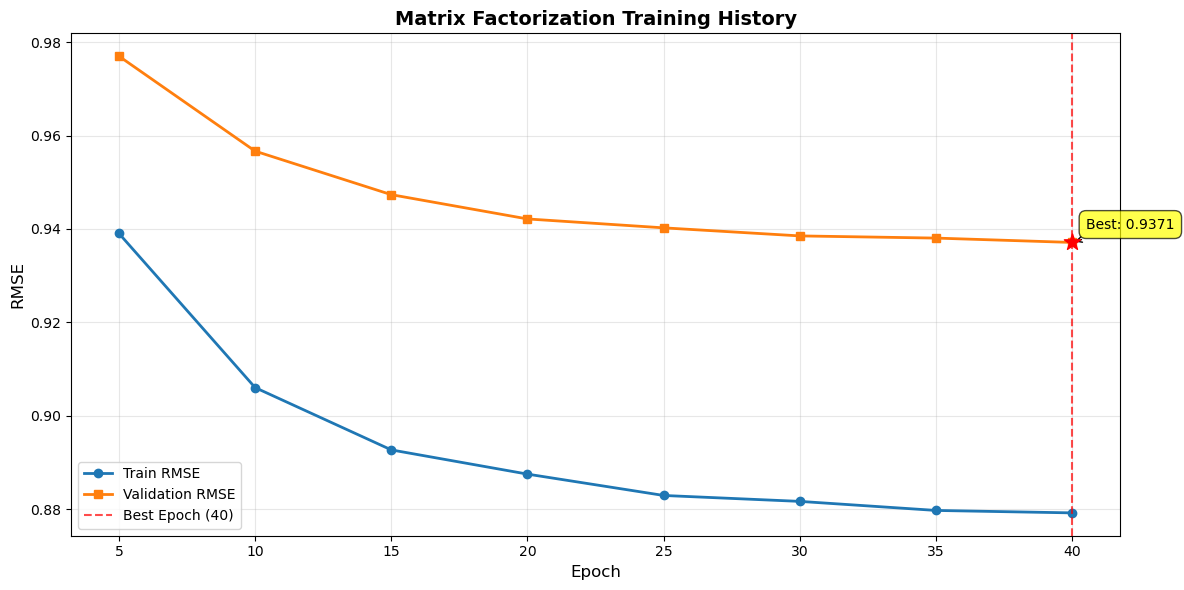


Final Train: 0.8792, Val: 0.9371
Best Val: 0.9371 (Epoch 40)


In [ ]:
mf_model, mf_predictions = train_and_predict_best(
    model_class=MatrixFactorizationSGD,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    param_grid={
        'n_factors': [60, 80],
        'learning_rate': [0.002],
        'n_epochs': [40],
        'use_bias': [True],
        'eval_every': [5],
        'batch_size': [1024],
        'device': ['auto'],
        'l2_reg': [0.2]
    },
    output_filepath='preds/predictions_mf_best.csv',
    metric='rmse'
)

mf_model.plot_training_history()
optimal_epochs = mf_model.get_best_epoch()

should_retrain = optimal_epochs is not None and optimal_epochs < mf_model.n_epochs

if should_retrain:
    print(f"\nRetraining with {optimal_epochs} epochs (best val: {mf_model.best_val_rmse:.4f})")

    mf_model = MatrixFactorizationSGD(
        n_factors=mf_model.n_factors,
        learning_rate=mf_model.learning_rate,
        n_epochs=optimal_epochs,
        use_bias=mf_model.use_bias,
        eval_every=mf_model.eval_every,
        batch_size=mf_model.batch_size,
        l2_reg=mf_model.l2_reg,
        device='auto'
    ).fit(train_data, val_data)

    print(f"Training complete: {optimal_epochs} epochs, Val RMSE: {mf_model.best_val_rmse:.4f}")

### Fit Matrix Factorization for Ranking

In [227]:
mf_ndcg_model, mf_ndcg_predictions = train_and_predict_best(
    model_class=MatrixFactorizationSGD,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    param_grid={
        'n_factors': [75],
        'learning_rate': [0.01],
        'n_epochs': [20],
        'use_bias': [True],
        'eval_every': [30],
        'batch_size': [1024],
        'device': ['auto'],
        'l2_reg': [0.1]
    },
    output_filepath='preds/predictions_mf_ndcg.csv',
    metric='ndcg',
    model_name='Matrix Factorization (NDCG-optimized)'
)

print("="*80)

mf_ndcg_ranking_metrics = evaluate_ranking_metrics(
    model=mf_ndcg_model,
    test_data=test_data,
    train_data=train_data,
    n=10,
    relevance_threshold=3.0
)

print(f"\nRanking Performance (NDCG-optimized):")
print(f"  Precision@10: {mf_ndcg_ranking_metrics['precision@10']:.4f}")
print(f"  Recall@10:    {mf_ndcg_ranking_metrics['recall@10']:.4f}")
print(f"  NDCG@10:      {mf_ndcg_ranking_metrics['ndcg@10']:.4f}")


Hyperparameter Sweep for MatrixFactorizationSGD | Metric: NDCG
Testing {'n_factors': 75, 'learning_rate': 0.01, 'n_epochs': 20, 'use_bias': True, 'eval_every': 30, 'batch_size': 1024, 'device': 'auto', 'l2_reg': 0.1}
Device: mps


Training MF: 100%|██████████| 20/20 [00:34<00:00,  1.73s/it]


Best val RMSE: 0.9277 at epoch 20


Fast eval@10: 100%|██████████| 459/459 [00:00<00:00, 1028.63it/s]


Validation NDCG@10 = 0.1479

Best params: {'n_factors': 75, 'learning_rate': 0.01, 'n_epochs': 20, 'use_bias': True, 'eval_every': 30, 'batch_size': 1024, 'device': 'auto', 'l2_reg': 0.1} | Best NDCG: 0.1479

Training final model with best params: {'n_factors': 75, 'learning_rate': 0.01, 'n_epochs': 20, 'use_bias': True, 'eval_every': 30, 'batch_size': 1024, 'device': 'auto', 'l2_reg': 0.1}
Device: mps


...

Best val RMSE: 0.9270 at epoch 20
Generating predictions using Matrix Factorization (NDCG-optimized) {'n_factors': 75, 'learning_rate': 0.01, 'n_epochs': 20, 'use_bias': True, 'eval_every': 30, 'batch_size': 1024, 'device': 'auto', 'l2_reg': 0.1}...


Matrix Factorization (NDCG-optimized) {'n_factors': 75, 'learning_rate': 0.01, 'n_epochs': 20, 'use_bias': True, 'eval_every': 30, 'batch_size': 1024, 'device': 'auto', 'l2_reg': 0.1} Predictions: 100%|██████████| 20000/20000 [00:20<00:00, 977.38it/s] 



Predictions saved to: preds/predictions_mf_ndcg.csv
Results for Matrix Factorization (NDCG-optimized) {'n_factors': 75, 'learning_rate': 0.01, 'n_epochs': 20, 'use_bias': True, 'eval_every': 30, 'batch_size': 1024, 'device': 'auto', 'l2_reg': 0.1}:
   - Total predictions: 20000
   - RMSE: 0.9270
   - MAE: 0.7281
Done. Best NDCG: 0.1479 | Saved to: preds/predictions_mf_ndcg.csv


Fast eval@10: 100%|██████████| 459/459 [00:00<00:00, 869.27it/s]


Ranking Performance (NDCG-optimized):
  Precision@10: 0.0791
  Recall@10:    0.0225
  NDCG@10:      0.1443


### Bayesian Probabilistic Ranking

In [ ]:
class BPRDataset(Dataset):
    
    def __init__(self, triples):
        self.triples = torch.LongTensor(triples)
    
    def __len__(self):
        return len(self.triples)
    
    def __getitem__(self, idx):
        return self.triples[idx]


class BayesianProbabilisticRanking:
    """Bayesian Personalized Ranking with L2 regularization."""

    def __init__(self, n_factors, learning_rate, n_epochs, n_samples, eval_every, 
                 batch_size, device, l2_reg=0.01):
        self.n_factors = n_factors
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.n_samples = n_samples
        self.eval_every = eval_every
        self.batch_size = batch_size
        self.l2_reg = l2_reg
        
        if device == 'auto':
            self.device = torch.device('mps' if torch.backends.mps.is_available() 
                                      else 'cuda' if torch.cuda.is_available() 
                                      else 'cpu')
        else:
            self.device = torch.device(device)
        
        print(f"Using device: {self.device}")
        print(f"L2 Regularization: {self.l2_reg}")
        
        self.P = None
        self.Q = None
        self.user_bias = None
        self.item_bias = None
        self.user_mapping = None
        self.item_mapping = None
        self.user_inv = None
        self.item_inv = None
        self.global_mean = None
        self.user_means = None
        
        self.history = {
            'train_loss': [],
            'val_rmse': [],
            'epochs': []
        }
        self.best_epoch = None
        self.best_val_rmse = float('inf')

    def _generate_training_triples(self, ratings):
        triples = []
        user_items = ratings.groupby('user_id')['item_id'].apply(set).to_dict()
        all_items = set(ratings['item_id'].unique())

        for user_id, rated_items in user_items.items():
            user_idx = self.user_mapping[user_id]
            unrated_items = list(all_items - rated_items)
            if len(unrated_items) == 0:
                continue
            
            rated_items_list = list(rated_items)
            for pos_item_id in rated_items_list:
                pos_item_idx = self.item_mapping[pos_item_id]
                n_neg = min(self.n_samples, len(unrated_items))
                neg_item_ids = np.random.choice(unrated_items, size=n_neg, replace=False)
                for neg_item_id in neg_item_ids:
                    neg_item_idx = self.item_mapping[neg_item_id]
                    triples.append([user_idx, pos_item_idx, neg_item_idx])
        
        return np.array(triples)

    def _should_evaluate(self, epoch):
        return (epoch + 1) % self.eval_every == 0 or (epoch + 1) == self.n_epochs or epoch == 0

    def _compute_rmse_gpu(self, data):
        self.P.eval()
        self.Q.eval()
        if self.user_bias is not None:
            self.user_bias.eval()
            self.item_bias.eval()
        
        user_ids = []
        item_ids = []
        true_ratings = []
        
        for _, row in data[['user_id', 'item_id', 'rating']].iterrows():
            user_ids.append(row['user_id'])
            item_ids.append(row['item_id'])
            true_ratings.append(row['rating'])
        
        preds = []
        batch_size = 1000
        for i in range(0, len(user_ids), batch_size):
            batch_users = user_ids[i:i+batch_size]
            batch_items = item_ids[i:i+batch_size]
            
            batch_preds = []
            for u, it in zip(batch_users, batch_items):
                pred = self.predict_rating(u, it)
                batch_preds.append(pred)
            
            preds.extend(batch_preds)
        
        preds = np.array(preds)
        true_ratings = np.array(true_ratings)
        
        return float(np.sqrt(mean_squared_error(true_ratings, preds)))

    def _track_metrics(self, epoch, avg_loss, val_data):
        self.history['train_loss'].append(avg_loss)
        self.history['epochs'].append(epoch + 1)
        
        if val_data is not None:
            val_rmse = self._compute_rmse_gpu(val_data)
            self.history['val_rmse'].append(val_rmse)
            
            if val_rmse < self.best_val_rmse:
                self.best_val_rmse = val_rmse
                self.best_epoch = epoch + 1

    def fit(self, train_data, val_data):
        self.train_data = train_data
        self.user_mapping = {u: i for i, u in enumerate(train_data['user_id'].unique())}
        self.item_mapping = {i: j for j, i in enumerate(train_data['item_id'].unique())}
        self.user_inv = {i: u for u, i in self.user_mapping.items()}
        self.item_inv = {j: i for i, j in self.item_mapping.items()}

        self.global_mean = float(train_data['rating'].mean())
        self.user_means = train_data.groupby('user_id')['rating'].mean().to_dict()
        print(f"Global mean: {self.global_mean:.4f}")
        
        n_users = len(self.user_mapping)
        n_items = len(self.item_mapping)

        self.P = torch.nn.Embedding(n_users, self.n_factors).to(self.device)
        self.Q = torch.nn.Embedding(n_items, self.n_factors).to(self.device)
        
        torch.nn.init.normal_(self.P.weight, mean=0, std=0.01)
        torch.nn.init.normal_(self.Q.weight, mean=0, std=0.01)

        self.user_bias = torch.nn.Embedding(n_users, 1).to(self.device)
        self.item_bias = torch.nn.Embedding(n_items, 1).to(self.device)
        torch.nn.init.zeros_(self.user_bias.weight)
        torch.nn.init.zeros_(self.item_bias.weight)

        optimizer = optim.Adam(
            list(self.P.parameters()) + 
            list(self.Q.parameters()) +
            list(self.user_bias.parameters()) +
            list(self.item_bias.parameters()),
            lr=self.learning_rate
        )

        self.history = {'train_loss': [], 'val_rmse': [], 'epochs': []}
        self.best_val_rmse = float('inf')
        self.best_epoch = None

        for epoch in tqdm(range(self.n_epochs), desc="Training BPR"):
            self.P.train()
            self.Q.train()
            self.user_bias.train()
            self.item_bias.train()
            
            triples = self._generate_training_triples(train_data)
            np.random.shuffle(triples)
            
            dataset = BPRDataset(triples)
            dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
            
            epoch_loss = 0.0
            n_batches = 0
            
            for batch in dataloader:
                batch = batch.to(self.device)
                users = batch[:, 0]
                pos_items = batch[:, 1]
                neg_items = batch[:, 2]
                
                user_emb = self.P(users)
                pos_item_emb = self.Q(pos_items)
                neg_item_emb = self.Q(neg_items)
                
                pos_scores = (user_emb * pos_item_emb).sum(dim=1)
                neg_scores = (user_emb * neg_item_emb).sum(dim=1)
                
                bpr_loss = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-10).mean()
                
                l2_loss = 0.0
                if self.l2_reg > 0:
                    l2_loss = (
                        self.l2_reg * (
                            user_emb.pow(2).sum() + 
                            pos_item_emb.pow(2).sum() + 
                            neg_item_emb.pow(2).sum()
                        )
                    ) / users.size(0)
                    
                    l2_loss += (
                        self.l2_reg * 0.1 * (
                            self.user_bias(users).pow(2).sum() +
                            self.item_bias(pos_items).pow(2).sum() +
                            self.item_bias(neg_items).pow(2).sum()
                        )
                    ) / users.size(0)
                
                loss = bpr_loss + l2_loss
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                epoch_loss += bpr_loss.item()
                n_batches += 1
            
            avg_loss = epoch_loss / n_batches if n_batches > 0 else 0.0
            
            if self._should_evaluate(epoch):
                self._track_metrics(epoch, avg_loss, val_data)
                if self.history['val_rmse']:
                    print(f"Epoch {epoch+1}/{self.n_epochs} - Loss: {avg_loss:.4f} - Val RMSE: {self.history['val_rmse'][-1]:.4f}")
        
        if self.best_epoch is not None:
            print(f"\nBest validation RMSE: {self.best_val_rmse:.4f} at epoch {self.best_epoch}")
        
        return self

    def predict_rating(self, user_id, item_id):
        """Predict rating using bias terms for better accuracy."""
        if user_id not in self.user_mapping or item_id not in self.item_mapping:
            if user_id in self.user_means:
                return float(self.user_means[user_id])
            return float(self.global_mean)
        
        self.P.eval()
        self.Q.eval()
        self.user_bias.eval()
        self.item_bias.eval()
        
        with torch.no_grad():
            u = torch.LongTensor([self.user_mapping[user_id]]).to(self.device)
            i = torch.LongTensor([self.item_mapping[item_id]]).to(self.device)
            
            user_emb = self.P(u)
            item_emb = self.Q(i)
            
            score = (
                self.global_mean +
                self.user_bias(u).item() +
                self.item_bias(i).item() +
                torch.dot(user_emb[0], item_emb[0]).item()
            )
            
            return float(np.clip(score, 1.0, 5.0))

    def recommend_topk(self, user_id, n=10):
        """Generate top-N recommendations for ranking tasks."""
        if user_id not in self.user_mapping:
            return []
        
        self.P.eval()
        self.Q.eval()
        self.user_bias.eval()
        self.item_bias.eval()
        
        with torch.no_grad():
            u = torch.LongTensor([self.user_mapping[user_id]]).to(self.device)
            user_emb = self.P(u)
            
            scores = torch.matmul(user_emb, self.Q.weight.T)[0]
            scores = scores + self.user_bias(u).item()
            scores = scores + self.item_bias.weight.squeeze()
            
            scores = scores.cpu().numpy()
        
        seen_items = self.train_data[self.train_data['user_id'] == user_id]['item_id'].values
        seen_idx = [self.item_mapping[i] for i in seen_items if i in self.item_mapping]
        scores[seen_idx] = -np.inf
        
        top_idx = np.argsort(scores)[::-1][:n]
        top_items = [self.item_inv[i] for i in top_idx]
        top_scores = scores[top_idx]
        
        return list(zip(top_items, top_scores))

    def get_training_history(self):
        return self.history
    
    def get_best_epoch(self):
        return self.best_epoch
    
    def plot_training_history(self, figsize=(12, 6), save_path=None):
        if not self.history['epochs']:
            print("No training history available. Train the model first.")
            return
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        ax1.plot(self.history['epochs'], self.history['train_loss'], 
                label='Train Loss', marker='o', linewidth=2, markersize=6, color='blue')
        ax1.set_xlabel('Epoch', fontsize=12)
        ax1.set_ylabel('Loss', fontsize=12)
        ax1.set_title('BPR Training Loss', fontsize=14, fontweight='bold')
        ax1.legend(fontsize=10)
        ax1.grid(True, alpha=0.3)
        
        if self.history['val_rmse']:
            ax2.plot(self.history['epochs'], self.history['val_rmse'], 
                    label='Validation RMSE', marker='s', linewidth=2, markersize=6, color='green')
            
            if self.best_epoch is not None:
                best_idx = self.history['epochs'].index(self.best_epoch)
                best_val_rmse = self.history['val_rmse'][best_idx]
                
                ax2.axvline(x=self.best_epoch, color='red', linestyle='--', 
                           label=f'Best Epoch ({self.best_epoch})', alpha=0.7)
                ax2.scatter([self.best_epoch], [best_val_rmse], 
                           color='red', s=150, zorder=5, marker='*')
                
                ax2.annotate(f'Best: {best_val_rmse:.4f}',
                           xy=(self.best_epoch, best_val_rmse),
                           xytext=(10, 10), textcoords='offset points',
                           bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
                           arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
            
            ax2.set_xlabel('Epoch', fontsize=12)
            ax2.set_ylabel('RMSE', fontsize=12)
            ax2.set_title('Validation RMSE', fontsize=14, fontweight='bold')
            ax2.legend(fontsize=10)
            ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Plot saved to: {save_path}")
        
        plt.show()
        
        if self.history['val_rmse']:
            final_val_rmse = self.history['val_rmse'][-1]
            print("\n" + "="*60)
            print("Training Summary:")
            print("="*60)
            print(f"Final Train Loss: {self.history['train_loss'][-1]:.4f}")
            print(f"Final Val RMSE: {final_val_rmse:.4f}")
            print(f"Best Val RMSE: {self.best_val_rmse:.4f} (Epoch {self.best_epoch})")
            
            if final_val_rmse > self.best_val_rmse:
                diff = final_val_rmse - self.best_val_rmse
                pct = (diff / self.best_val_rmse) * 100
                print(f"Overfitting detected: +{diff:.4f} ({pct:.2f}%)")
            else:
                print("No overfitting detected")
            print("="*60)


### Fit BPR for Rating


Hyperparameter Sweep for BayesianProbabilisticRanking
Testing parameters: {'n_factors': [50, 70], 'learning_rate': [0.001, 0.02], 'n_epochs': [30], 'n_samples': [5], 'eval_every': [5], 'batch_size': [512], 'device': ['auto'], 'l2_reg': [0.1]}
Optimization metric: RMSE


Testing: {'n_factors': 50, 'learning_rate': 0.001, 'n_epochs': 30, 'n_samples': 5, 'eval_every': 5, 'batch_size': 512, 'device': 'auto', 'l2_reg': 0.1}
Using device: mps
L2 Regularization: 0.1
Global mean: 3.5284


Training BPR:   3%|▎         | 1/30 [00:13<06:28, 13.41s/it]

Epoch 1/30 - Loss: 0.5320 - Val RMSE: 1.1467


Training BPR:  17%|█▋        | 5/30 [05:57<26:58, 64.74s/it]   

Epoch 5/30 - Loss: 0.4640 - Val RMSE: 1.1485


...

Epoch 25/30 - Loss: 0.4638 - Val RMSE: 1.1479


Training BPR: 100%|██████████| 30/30 [05:18<00:00, 10.60s/it]


Epoch 30/30 - Loss: 0.4626 - Val RMSE: 1.1501

Best validation RMSE: 1.1479 at epoch 25
Generating predictions using BayesianProbabilisticRanking {'n_factors': 50, 'learning_rate': 0.001, 'n_epochs': 30, 'n_samples': 5, 'eval_every': 5, 'batch_size': 512, 'device': 'auto', 'l2_reg': 0.1}...


BayesianProbabilisticRanking {'n_factors': 50, 'learning_rate': 0.001, 'n_epochs': 30, 'n_samples': 5, 'eval_every': 5, 'batch_size': 512, 'device': 'auto', 'l2_reg': 0.1} Predictions: 100%|██████████| 16000/16000 [00:17<00:00, 895.54it/s]



Predictions saved to: preds/predictions_bpr_best.csv
Results for BayesianProbabilisticRanking {'n_factors': 50, 'learning_rate': 0.001, 'n_epochs': 30, 'n_samples': 5, 'eval_every': 5, 'batch_size': 512, 'device': 'auto', 'l2_reg': 0.1}:
   - Total predictions: 16000
   - RMSE: 1.1554
   - MAE: 0.9063

Summary:
  - Best parameters: {'n_factors': 50, 'learning_rate': 0.001, 'n_epochs': 30, 'n_samples': 5, 'eval_every': 5, 'batch_size': 512, 'device': 'auto', 'l2_reg': 0.1}
  - Best RMSE: 1.1466
  - Predictions saved to: preds/predictions_bpr_best.csv



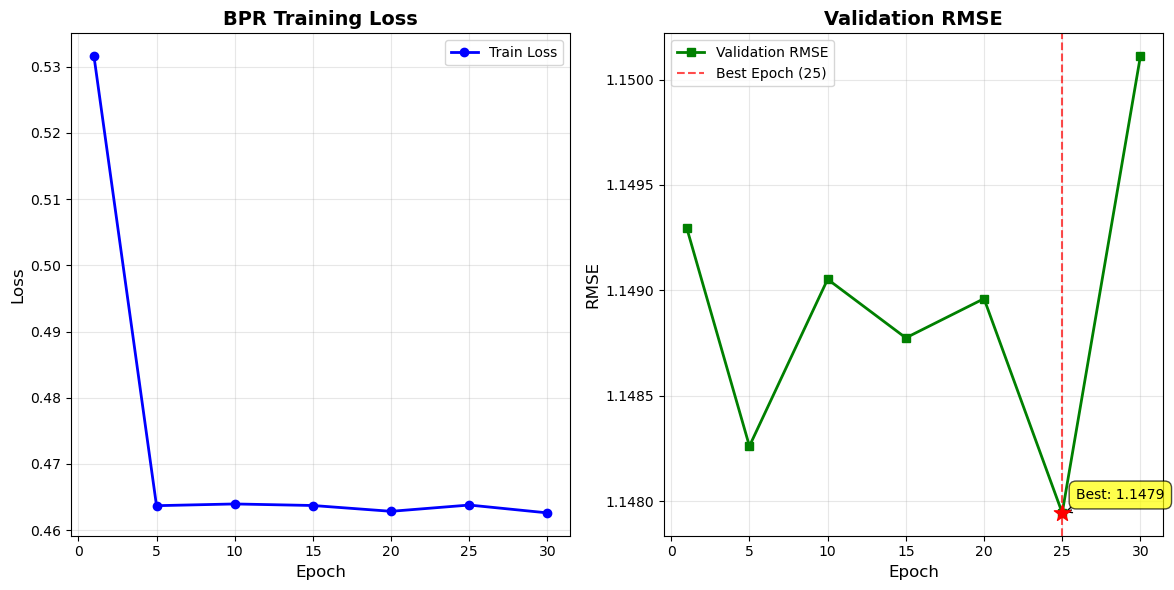


Training Summary:
Final Train Loss: 0.4626
Final Val RMSE: 1.1501
Best Val RMSE: 1.1479 (Epoch 25)
Overfitting detected: +0.0022 (0.19%)

STEP 3: Retraining BPR with optimal number of epochs
Optimal epoch found: 25
Best validation RMSE: 1.1479

Retraining model with 25 epochs...
Using device: mps
L2 Regularization: 0.1
Global mean: 3.5284


Training BPR:   4%|▍         | 1/25 [00:13<05:35, 14.00s/it]

Epoch 1/25 - Loss: 0.5332 - Val RMSE: 1.1485


Training BPR:  20%|██        | 5/25 [00:56<03:48, 11.44s/it]

Epoch 5/25 - Loss: 0.4639 - Val RMSE: 1.1494


...

Epoch 15/25 - Loss: 0.4639 - Val RMSE: 1.1487


Training BPR:  80%|████████  | 20/25 [03:36<00:55, 11.16s/it]

Epoch 20/25 - Loss: 0.4636 - Val RMSE: 1.1486


Training BPR: 100%|██████████| 25/25 [04:29<00:00, 10.78s/it]

Epoch 25/25 - Loss: 0.4640 - Val RMSE: 1.1465

Best validation RMSE: 1.1465 at epoch 25

BPR Training completed!
Final model trained with 25 epochs
Validation RMSE: 1.1465


In [ ]:
bpr_model, bpr_predictions = train_and_predict_best(
    model_class=BayesianProbabilisticRanking,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    param_grid={
        'n_factors': [50, 70],
        'learning_rate': [0.001, 0.02],
        'n_epochs': [30],
        'n_samples': [5],
        'eval_every': [5],
        'batch_size': [512],
        'device': ['auto'],
        'l2_reg': [0.1]
    },
    output_filepath='preds/predictions_bpr_best.csv',
    metric='rmse'
)

bpr_model.plot_training_history(figsize=(12, 6), save_path=None)
optimal_epochs_bpr = bpr_model.get_best_epoch()

should_retrain = (
    optimal_epochs_bpr is not None and 
    optimal_epochs_bpr < bpr_model.n_epochs
)

if should_retrain:
    print("\n" + "="*80)
    print("STEP 3: Retraining BPR with optimal number of epochs")
    print("="*80)
    print(f"Optimal epoch found: {optimal_epochs_bpr}")
    print(f"Best validation RMSE: {bpr_model.best_val_rmse:.4f}")
    print(f"\nRetraining model with {optimal_epochs_bpr} epochs...")

    bpr_final = BayesianProbabilisticRanking(
        n_factors=bpr_model.n_factors,
        learning_rate=bpr_model.learning_rate,
        n_epochs=optimal_epochs_bpr,
        n_samples=bpr_model.n_samples,
        eval_every=bpr_model.eval_every,
        batch_size=bpr_model.batch_size,
        l2_reg=bpr_model.l2_reg,
        device='auto'
    ).fit(train_data, val_data)

    print("\n" + "="*80)
    print("BPR Training completed!")
    print("="*80)
    print(f"Final model trained with {optimal_epochs_bpr} epochs")
    print(f"Validation RMSE: {bpr_final.best_val_rmse:.4f}")
    print("="*80)
else:
    print("\n" + "="*80)
    print("No retraining needed - using existing model")
    print("="*80)
    bpr_final = bpr_model

### Fit BPR for Ranking

In [ ]:
bpr_ndcg_model, bpr_ndcg_predictions = train_and_predict_best(
    model_class=BayesianProbabilisticRanking,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    param_grid={
        'n_factors': [32],
        'learning_rate': [0.01],
        'n_epochs': [30],
        'n_samples': [5],
        'eval_every': [40],
        'batch_size': [8192],
        'device': ['auto'],
        'l2_reg': [0.01]
    },
    output_filepath='preds/predictions_bpr_ndcg.csv',
    metric='ndcg',
    model_name='BPR (NDCG-optimized)'
)


print("\n" + "="*80)
print("EVALUATING NDCG-OPTIMIZED BPR MODEL")
print("="*80)

bpr_ndcg_ranking_metrics = evaluate_ranking_metrics(
    model=bpr_ndcg_model,
    test_data=test_data,
    train_data=train_data,
    n=10,
    relevance_threshold=1.0
)

print(f"\nRanking Performance (NDCG-optimized):")
print(f"  Precision@10: {bpr_ndcg_ranking_metrics['precision@10']:.4f}")
print(f"  Recall@10:    {bpr_ndcg_ranking_metrics['recall@10']:.4f}")
print(f"  NDCG@10:      {bpr_ndcg_ranking_metrics['ndcg@10']:.4f}")




BPR: HYPERPARAMETER TUNING FOR NDCG@10

Hyperparameter Sweep for BayesianProbabilisticRanking
Testing parameters: {'n_factors': [50, 70], 'learning_rate': [0.002], 'n_epochs': [30], 'n_samples': [5], 'eval_every': [15], 'batch_size': [512], 'device': ['auto'], 'l2_reg': [0.1, 0.2]}
Optimization metric: NDCG


Testing: {'n_factors': 50, 'learning_rate': 0.002, 'n_epochs': 30, 'n_samples': 5, 'eval_every': 15, 'batch_size': 512, 'device': 'auto', 'l2_reg': 0.1}
Using device: mps
L2 Regularization: 0.1
Global mean: 3.5284


Training BPR:   3%|▎         | 1/30 [00:14<06:49, 14.12s/it]

Epoch 1/30 - Loss: 0.5061 - Val RMSE: 1.1495


Training BPR:  50%|█████     | 15/30 [02:37<02:47, 11.18s/it]

Epoch 15/30 - Loss: 0.4636 - Val RMSE: 1.1492


...

Epoch 30/30 - Loss: 0.4634 - Val RMSE: 1.1508

Best validation RMSE: 1.1482 at epoch 15
Generating predictions using BPR (NDCG-optimized) {'n_factors': 50, 'learning_rate': 0.002, 'n_epochs': 30, 'n_samples': 5, 'eval_every': 15, 'batch_size': 512, 'device': 'auto', 'l2_reg': 0.1}...


BPR (NDCG-optimized) {'n_factors': 50, 'learning_rate': 0.002, 'n_epochs': 30, 'n_samples': 5, 'eval_every': 15, 'batch_size': 512, 'device': 'auto', 'l2_reg': 0.1} Predictions: 100%|██████████| 16000/16000 [00:15<00:00, 1002.86it/s]



Predictions saved to: preds/predictions_bpr_ndcg.csv
Results for BPR (NDCG-optimized) {'n_factors': 50, 'learning_rate': 0.002, 'n_epochs': 30, 'n_samples': 5, 'eval_every': 15, 'batch_size': 512, 'device': 'auto', 'l2_reg': 0.1}:
   - Total predictions: 16000
   - RMSE: 1.1577
   - MAE: 0.9080

Summary:
  - Best parameters: {'n_factors': 50, 'learning_rate': 0.002, 'n_epochs': 30, 'n_samples': 5, 'eval_every': 15, 'batch_size': 512, 'device': 'auto', 'l2_reg': 0.1}
  - Best NDCG: 0.0841
  - Predictions saved to: preds/predictions_bpr_ndcg.csv


EVALUATING NDCG-OPTIMIZED BPR MODEL


Evaluating ranking metrics @10: 100%|██████████| 459/459 [00:00<00:00, 1056.80it/s]


Ranking Performance (NDCG-optimized):
  Precision@10: 0.2137
  Recall@10:    0.0930
  NDCG@10:      0.1778


### Hybrid-model

In [ ]:
class HybridRecommender:
    """Hybrid recommender with learnable weights over pre-trained component models using Ridge Regression (L2)."""

    def __init__(self, models: Dict[str, object], weights: Optional[Dict[str, float]] = None,
                 prediction_files: Optional[Dict[str, str]] = None, alpha: float = 1.0):
        self.models = models
        self.prediction_files = prediction_files
        self.regression_model = None
        self.scaler = StandardScaler()
        self.alpha = alpha
        
        if weights is None:
            n_models = len(models)
            self.weights = {name: 1.0 / n_models for name in models.keys()}
        else:
            total = sum(weights.values())
            self.weights = {name: w / total for name, w in weights.items()}
        
        self.train_data = None
        self.global_mean = None
        self.user_means = None
        self.model_names = list(models.keys())
        self.cached_predictions = {}
        
        self._validate_models()

    def _validate_models(self):
        for name, model in self.models.items():
            if not hasattr(model, 'predict_rating'):
                raise ValueError(f"Model '{name}' must have 'predict_rating' method")
            
            if hasattr(model, 'user_mapping') and model.user_mapping is None:
                raise ValueError(f"Model '{name}' appears to be unfitted.")

    def _load_predictions_from_files(self, validation_data: pd.DataFrame):
        """Load predictions from CSV files."""        
        for model_name in self.model_names:
            if model_name not in self.prediction_files:
                raise ValueError(f"No prediction file specified for model '{model_name}'")
            
            filepath = self.prediction_files[model_name]
            if not os.path.exists(filepath):
                raise FileNotFoundError(f"Prediction file not found: {filepath}")
            
            pred_df = pd.read_csv(filepath)
            pred_dict = {}
            
            for _, row in pred_df.iterrows():
                key = (int(row['user_id']), int(row['item_id']))
                pred_dict[key] = float(row['predicted_rating'])
            
            self.cached_predictions[model_name] = pred_dict
            print(f"  ✓ Loaded {len(pred_dict)} predictions for {model_name}")

    def fit(self, train_data: pd.DataFrame, validation_data: Optional[pd.DataFrame] = None):
        """Learn optimal weights for pre-trained models."""
        self.train_data = train_data
        self.global_mean = train_data['rating'].mean()
        self.user_means = train_data.groupby('user_id')['rating'].mean().to_dict()
        
        if validation_data is not None:
            if self.prediction_files:
                self._load_predictions_from_files(validation_data)
            self._learn_weights(validation_data)
        
        return self

    def _learn_weights(self, validation_data: pd.DataFrame):
        """Learn weights via Ridge regression (L2 regularization) on validation predictions."""
        X, y = [], []
        valid_pairs, skipped_pairs = 0, 0

        for _, row in tqdm(validation_data.iterrows(), total=len(validation_data), desc="Collecting predictions"):
            user_id = int(row['user_id'])
            item_id = int(row['item_id'])
            true_rating = float(row['rating'])
            key = (user_id, item_id)
            
            predictions = []
            all_valid = True
            
            for model_name in self.model_names:
                if self.cached_predictions and model_name in self.cached_predictions:
                    pred = self.cached_predictions[model_name].get(key)
                    if pred is None:
                        all_valid = False
                        break
                    predictions.append(pred)
                else:
                    model = self.models[model_name]
                    try:
                        pred = model.predict_rating(user_id, item_id)
                        if pred is None or (isinstance(pred, float) and np.isnan(pred)):
                            pred = self.user_means.get(user_id, self.global_mean)
                        predictions.append(float(pred))
                    except Exception:
                        all_valid = False
                        break

            if all_valid and len(predictions) == len(self.models):
                X.append(predictions)
                y.append(true_rating)
                valid_pairs += 1
            else:
                skipped_pairs += 1

        print(f"\n  Valid pairs: {valid_pairs}")
        print(f"  Skipped pairs: {skipped_pairs}")

        if len(X) == 0:
            print("\n⚠ Warning: No valid predictions. Using equal weights.")
            return

        X = np.array(X)
        y = np.array(y)

        print(f"\nFeature matrix shape: {X.shape}")
        print(f"Target vector shape: {y.shape}")

        X_scaled = self.scaler.fit_transform(X)
        self.regression_model = Ridge(alpha=self.alpha, fit_intercept=True)
        self.regression_model.fit(X_scaled, y)
        
        learned_weights = self.regression_model.coef_
        intercept = self.regression_model.intercept_

        print(f"\n✓ Ridge Regression model trained (alpha={self.alpha})!")
        print(f"  Intercept (bias): {intercept:.4f}")
        print(f"  Raw coefficients: {learned_weights}")

        abs_weights = np.abs(learned_weights)
        if abs_weights.sum() > 0:
            normalized_weights = abs_weights / abs_weights.sum()
        else:
            normalized_weights = np.ones(len(learned_weights)) / len(learned_weights)

        self.weights = {
            name: float(weight)
            for name, weight in zip(self.model_names, normalized_weights)
        }

        print(f"\n✓ Learned weights (normalized):")
        for name, weight in self.weights.items():
            print(f"    {name:20s}: {weight:.4f} ({weight*100:.1f}%)")

        val_rmse = self._evaluate_on_data(X, y)
        print(f"\n  Validation RMSE: {val_rmse:.4f}")

    def _evaluate_on_data(self, X: np.ndarray, y: np.ndarray) -> float:
        """Evaluate RMSE on given data."""
        if self.regression_model is None:
            return float('inf')
        X_scaled = self.scaler.transform(X)
        predictions = self.regression_model.predict(X_scaled)
        predictions = np.clip(predictions, 1.0, 5.0)
        return float(np.sqrt(np.mean((predictions - y) ** 2)))

    def predict_rating(self, user_id: int, item_id: int) -> float:
        """Predict a rating using the hybrid model."""
        predictions = []
        
        for model_name, model in self.models.items():
            try:
                pred = model.predict_rating(user_id, item_id)
                
                if pred is None or (isinstance(pred, float) and np.isnan(pred)):
                    pred = self.user_means.get(user_id, self.global_mean)
                
                predictions.append(float(pred))
            except Exception:
                predictions.append(self.global_mean)

        if len(predictions) == 0:
            return self.global_mean

        if self.regression_model is not None:
            X = np.array([predictions])
            X_scaled = self.scaler.transform(X)
            pred = self.regression_model.predict(X_scaled)[0]
            return float(np.clip(pred, 1.0, 5.0))

        weights = [self.weights[name] for name in self.model_names]
        total_weight = sum(weights)
        if total_weight == 0:
            return float(np.mean(predictions))
        
        weighted_pred = sum(p * w for p, w in zip(predictions, weights)) / total_weight
        return float(np.clip(weighted_pred, 1.0, 5.0))

    def recommend_topk(self, user_id: int, n: int = 10) -> List[Tuple[int, float]]:
        """Generate top-N recommendations for a user."""
        if self.train_data is None:
            return []
        
        seen_items = set(self.train_data[self.train_data['user_id'] == user_id]['item_id'].unique())
        all_items = set(self.train_data['item_id'].unique())
        candidate_items = all_items - seen_items
        
        if not candidate_items:
            return []
        
        scores = []
        for item in candidate_items:
            pred = self.predict_rating(user_id, item)
            scores.append((item, float(pred)))
        
        scores.sort(key=lambda x: x[1], reverse=True)
        return scores[:n]

    def get_weights(self) -> Dict[str, float]:
        """Return current model weights."""
        return self.weights.copy()

    def get_feature_importance(self) -> pd.DataFrame:
        """Return learned coefficients and normalized weights."""
        if self.regression_model is None:
            return pd.DataFrame({
                'model': self.model_names,
                'weight': [self.weights[name] for name in self.model_names],
            })
        
        return pd.DataFrame({
            'model': self.model_names,
            'weight': [self.weights[name] for name in self.model_names],
        }).sort_values('weight', ascending=False)

In [ ]:
content_val_preds = save_predictions_to_csv(
    model=content_model_best,
    test_data=val_data,
    output_filepath='preds/predictions_content_val.csv',
    model_name='Content'
)

user_knn_val_preds = save_predictions_to_csv(
    model=user_knn_model,
    test_data=val_data,
    output_filepath='preds/predictions_userknn_val.csv',
    model_name='UserKNN'
)

item_knn_val_preds = save_predictions_to_csv(
    model=item_knn_model,
    test_data=val_data,
    output_filepath='preds/predictions_itemknn_val.csv',
    model_name='ItemKNN'
)

mf_val_preds = save_predictions_to_csv(
    model=mf_model,
    test_data=val_data,
    output_filepath='preds/predictions_mf_val.csv',
    model_name='MF'
)

hybrid_model = HybridRecommender(
    models={
        'Content': content_model_best,
        'UserKNN': user_knn_model,
        'ItemKNN': item_knn_model,
        'MF': mf_model},
    prediction_files={
        'Content': 'preds/predictions_content_val.csv',
        'UserKNN': 'preds/predictions_userknn_val.csv',
        'ItemKNN': 'preds/predictions_itemknn_val.csv',
        'MF': 'preds/predictions_mf_val.csv'},
    alpha=1.0
)

hybrid_model.fit(train_data, validation_data=val_data)


print("\n" + "="*80)
print("LEARNED WEIGHTS:")
print("="*80)
weights_df = hybrid_model.get_feature_importance()
display(weights_df)

print("\n" + "="*80)
print("GENERATING PREDICTIONS ON TEST SET")
print("="*80)

hybrid_predictions = save_predictions_to_csv(
    model=hybrid_model,
    test_data=test_data,
    output_filepath='preds/predictions_hybrid.csv',
    model_name='Hybrid Recommender'
)

print("\n" + "="*80)
print("EVALUATION")
print("="*80)
hybrid_rmse = evaluate_rmse(hybrid_model, test_data)
print(f"Hybrid Model RMSE: {hybrid_rmse:.4f}")

Generating predictions using Content...


Content Predictions: 100%|██████████| 4000/4000 [00:00<00:00, 20394.63it/s]



Predictions saved to: preds/predictions_content_val.csv
Results for Content:
   - Total predictions: 4000
   - RMSE: 1.1654
   - MAE: 0.9023
Generating predictions using UserKNN...


UserKNN Predictions: 100%|██████████| 4000/4000 [02:13<00:00, 29.85it/s]



Predictions saved to: preds/predictions_userknn_val.csv
Results for UserKNN:
   - Total predictions: 4000
   - RMSE: 0.9593
   - MAE: 0.7466
Generating predictions using ItemKNN...


...


GENERATING PREDICTIONS ON TEST SET
Generating predictions using Hybrid Recommender...


Hybrid Recommender Predictions: 100%|██████████| 16000/16000 [09:45<00:00, 27.33it/s]



Predictions saved to: preds/predictions_hybrid.csv
Results for Hybrid Recommender:
   - Total predictions: 16000
   - RMSE: 0.9250
   - MAE: 0.7285

EVALUATION


100%|██████████| 16000/16000 [19:02<00:00, 14.00it/s]   

Hybrid Model RMSE: 0.9250


### Fit Hybrid for Ranking

In [ ]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple, List
from tqdm import tqdm

class OptimizedHybridRanking:
    def __init__(
        self,
        models: Dict[str, object],
        train_data: pd.DataFrame,
        relevance_threshold: float = 3.0,
        normalize_per_user: bool = True,
        n_dirichlet: int = 300,
        coord_iters: int = 10,
        coord_grid: Tuple[float, ...] = (0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0)
    ):
        self.models = models
        self.train_data = train_data
        self.relevance_threshold = relevance_threshold
        self.normalize_per_user = normalize_per_user
        self.n_dirichlet = n_dirichlet
        self.coord_iters = coord_iters
        self.coord_grid = coord_grid

        self.model_names = list(models.keys())
        self.weights = {name: 1.0 / len(self.model_names) for name in self.model_names}

        self.predictions_df = None
        self.model_cols = []
        self.user_top10 = {}

    # ---------- utils ----------
    def _minmax_per_user(self, df, cols):
        def _mm(g):
            g = g.copy()
            for c in cols:
                vmin, vmax = g[c].min(), g[c].max()
                g[c] = (g[c] - vmin) / (vmax - vmin) if vmax > vmin else 0.5
            return g
        return df.groupby("user_id", group_keys=False).apply(_mm)

    def _dcg_at_10(self, rels):
        rels = np.asarray(rels[:10], float)
        if rels.size == 0:
            return 0.0
        denom = np.log2(np.arange(2, 2 + rels.size))
        return float(np.sum((2.0**rels - 1.0) / denom))

    def _project_simplex(self, v):
        v = np.asarray(v, float)
        n = v.size
        u = np.sort(v)[::-1]
        cssv = np.cumsum(u)
        rho = np.where(u - (cssv - 1) / (np.arange(n) + 1) > 0)[0][-1]
        theta = (cssv[rho] - 1) / (rho + 1.0)
        return np.maximum(v - theta, 0.0)

    # ---------- generate predictions for all user-item pairs ----------
    def _generate_all_predictions(self, val_data):
        """Generate predictions for all possible user-item pairs."""
        print("\n" + "="*80)
        print("GENERATING PREDICTIONS FOR ALL USER-ITEM PAIRS")
        print("="*80)

        users = self.train_data['user_id'].unique()
        items = self.train_data['item_id'].unique()
        
        print(f"  Users: {len(users):,}")
        print(f"  Items: {len(items):,}")
        print(f"  Total pairs: {len(users) * len(items):,}")

        rows = []
        for user_id in tqdm(users, desc="Generating predictions"):
            for item_id in items:
                row_data = {'user_id': user_id, 'item_id': item_id}
                
                # Get predictions from each model
                for model_name, model in self.models.items():
                    try:
                        pred = model.predict_rating(user_id, item_id)
                        row_data[f'score__{model_name}'] = float(pred)
                    except Exception as e:
                        # Fallback to global mean if prediction fails
                        row_data[f'score__{model_name}'] = 3.0
                
                rows.append(row_data)

        df = pd.DataFrame(rows)
        
        # Add ground truth (only for validation set items)
        df_gt = val_data[["user_id", "item_id", "rating"]].copy()
        df = df.merge(df_gt, on=["user_id", "item_id"], how="left")
        df["rel"] = (df["rating"] >= self.relevance_threshold).astype(float)
        df.loc[df["rating"].isna(), "rel"] = 0.0

        self.model_cols = [c for c in df.columns if c.startswith("score__")]
        
        if self.normalize_per_user:
            print("  Normalizing per user ...")
            df = self._minmax_per_user(df, self.model_cols)

        self.predictions_df = df
        print(f"  Final shape: {df.shape}")
        print(f"  Model columns: {len(self.model_cols)}")

    # ---------- ndcg evaluation ----------
    def _eval_ndcg10(self, df, w):
        """Compute NDCG@10 using full ranking (no leakage)."""
        df_temp = df.copy()
        df_temp["hybrid"] = df_temp[self.model_cols].values @ w
        ndcgs = []

        for uid, g in df_temp.groupby("user_id"):
            # Full ranking of all candidate items
            g_sorted = g.sort_values("hybrid", ascending=False)
            top = g_sorted.head(10)

            # Get relevance only for items actually rated in validation set
            rels = []
            rated = g[g["rating"].notna()]
            if rated.empty:
                continue
            
            for iid in top["item_id"]:
                if iid in rated["item_id"].values:
                    rels.append(rated.loc[rated["item_id"] == iid, "rel"].values[0])
                else:
                    rels.append(0.0)

            dcg = self._dcg_at_10(rels)
            idcg = self._dcg_at_10(np.sort(rated["rel"].values)[::-1])
            if idcg > 0:
                ndcgs.append(dcg / idcg)

        return 0.0 if not ndcgs else float(np.mean(ndcgs))

    # ---------- weight optimization ----------
    def fit_weights(self, val_data):
        """Learn optimal weights using validation data."""
        # First generate all predictions
        self._generate_all_predictions(val_data)
        
        print("\n" + "="*80)
        print("OPTIMIZING HYBRID WEIGHTS (FULL-RANKING NDCG)")
        print("="*80)

        df = self.predictions_df
        m = len(self.model_cols)

        best_w = np.ones(m) / m
        best_ndcg = self._eval_ndcg10(df, best_w)
        print(f"  Uniform NDCG@10: {best_ndcg:.4f}")

        # Random search with Dirichlet distribution
        for _ in tqdm(range(self.n_dirichlet), desc="Dirichlet search"):
            w_try = np.random.dirichlet(np.ones(m))
            nd = self._eval_ndcg10(df, w_try)
            if nd > best_ndcg:
                best_ndcg, best_w = nd, w_try

        # Coordinate descent refinement
        w = best_w.copy()
        for iteration in range(self.coord_iters):
            improved = False
            for j in range(m):
                base = w.copy()
                best_local = best_ndcg
                for g in self.coord_grid:
                    w_try = base.copy()
                    w_try[j] = g
                    w_try = self._project_simplex(w_try)
                    nd = self._eval_ndcg10(df, w_try)
                    if nd > best_local:
                        best_local, w = nd, w_try
                        improved = True
                        best_ndcg = nd
            if not improved:
                print(f"  Converged after {iteration + 1} iterations")
                break

        self.weights = {c.replace("score__", ""): float(wi) for c, wi in zip(self.model_cols, w)}
        print(f"\n✓ Final weights:")
        for name, val in self.weights.items():
            print(f"  {name:20s}: {val:.4f}")
        print(f"  Best NDCG@10: {best_ndcg:.4f}")
        return best_ndcg

    # ---------- precompute recommendations ----------
    def precompute_top10(self):
        """Precompute top-10 recommendations for all users."""
        print("\n" + "="*80)
        print("PRECOMPUTING TOP-10 RECOMMENDATIONS")
        print("="*80)
        
        df = self.predictions_df.copy()
        w = np.array([self.weights[c.replace("score__", "")] for c in self.model_cols])
        df["hybrid_score"] = df[self.model_cols].values @ w

        seen = self.train_data.groupby("user_id")["item_id"].apply(set).to_dict()
        self.user_top10 = {}

        for uid, g in tqdm(df.groupby("user_id"), desc="Computing Top-10"):
            # Filter out seen items
            unseen = g[~g["item_id"].isin(seen.get(uid, set()))]
            top = unseen.sort_values("hybrid_score", ascending=False).head(10)
            self.user_top10[uid] = list(zip(top["item_id"], top["hybrid_score"]))
        
        print(f"  ✓ Precomputed for {len(self.user_top10)} users")

    def recommend_topk(self, user_id, n=10):
        """Get top-N recommendations for a user."""
        return self.user_top10.get(user_id, [])[:n]

    def predict_rating(self, user_id, item_id):
        """Predict rating for a user-item pair."""
        if self.predictions_df is None:
            # Fallback: compute on-the-fly
            predictions = []
            for model_name, model in self.models.items():
                try:
                    pred = model.predict_rating(user_id, item_id)
                    predictions.append(float(pred))
                except:
                    predictions.append(3.0)
            
            w = np.array([self.weights[name] for name in self.model_names])
            return float(np.dot(predictions, w))
        
        # Use precomputed predictions
        row = self.predictions_df[
            (self.predictions_df["user_id"] == user_id) &
            (self.predictions_df["item_id"] == item_id)
        ]
        if row.empty:
            return 3.0
        
        w = np.array([self.weights[c.replace("score__", "")] for c in self.model_cols])
        return float(row[self.model_cols].values @ w)

    def get_weights(self):
        """Get learned weights."""
        return self.weights.copy()


# ==============================================================================
# USAGE EXAMPLE
# ==============================================================================

print("\n" + "="*80)
print("TRAINING HYBRID RANKING MODEL")
print("="*80)

hybrid = OptimizedHybridRanking(
    models={
        'Content': content_ndcg_model,
        'UserKNN': user_knn_ndcg_model,
        'ItemKNN': item_knn_ndcg_model,
        'MF': mf_ndcg_model,
        'BPR': bpr_ndcg_model
    },
    train_data=train_data,
    relevance_threshold=3.0,
    normalize_per_user=True,
    n_dirichlet=300,
    coord_iters=10
)

# Step 1: Learn weights on validation set
best_ndcg = hybrid.fit_weights(val_data)

# Step 2: Precompute recommendations
hybrid.precompute_top10()

# Step 3: Evaluate on test set
print("\n" + "="*80)
print("EVALUATING ON TEST SET")
print("="*80)

metrics = evaluate_ranking_metrics(
    model=hybrid,
    test_data=test_data,
    train_data=train_data,
    n=10,
    relevance_threshold=3.0
)

print("\nHybrid Ranking Model - Test Performance:")
print(f"  Precision@10: {metrics['precision@10']:.4f}")
print(f"  Recall@10:    {metrics['recall@10']:.4f}")
print(f"  NDCG@10:      {metrics['ndcg@10']:.4f}")
print(f"  Users evaluated: {metrics['num_users_evaluated']}")

print("\nLearned Weights:")
for name, weight in hybrid.get_weights().items():
    print(f"  {name:20s}: {weight:.4f} ({weight*100:.1f}%)")


LOADING ALL MODEL PREDICTIONS (FULL CANDIDATE SPACE)
  ✓ Content        : 20,000 predictions
  ✓ UserKNN        : 20,000 predictions
  ✓ ItemKNN        : 20,000 predictions
  ✓ MF             : 20,000 predictions
  ✓ BPR            : 20,000 predictions
  Normalizing per user ...
  Final shape: (20000, 9), users: 459

OPTIMIZING HYBRID WEIGHTS (FULL-RANKING NDCG)
  Uniform NDCG@10: 0.9496


Dirichlet search:   8%|▊         | 23/300 [00:09<01:55,  2.40it/s]


KeyboardInterrupt: 

In [202]:
import pandas as pd
from tqdm import tqdm

def save_full_predictions(model, train_data: pd.DataFrame, output_filepath: str):
    """
    Generate predictions for all possible user–item pairs in the dataset.
    (You’ll later filter seen items when evaluating.)
    """
    users = train_data['user_id'].unique()
    items = train_data['item_id'].unique()

    rows = []
    for user_id in tqdm(users, desc=f"Generating full-space predictions → {output_filepath}"):
        for item_id in items:
            pred = model.predict_rating(user_id, item_id)
            rows.append((user_id, item_id, float(pred)))

    df = pd.DataFrame(rows, columns=['user_id', 'item_id', 'predicted_rating'])
    df.to_csv(output_filepath, index=False)
    print(f"✓ Saved {len(df):,} predictions to {output_filepath}")
    return df

save_full_predictions(content_ndcg_model, train_data, "preds/full_predictions_content.csv")
save_full_predictions(user_knn_ndcg_model, train_data, "preds/full_predictions_userknn.csv")
save_full_predictions(item_knn_ndcg_model, train_data, "preds/full_predictions_itemknn.csv")
save_full_predictions(mf_ndcg_model, train_data, "preds/full_predictions_mf.csv")
save_full_predictions(bpr_ndcg_model, train_data, "preds/full_predictions_bpr.csv")



Generating full-space predictions → preds/full_predictions_content.csv: 100%|██████████| 943/943 [00:07<00:00, 117.93it/s]


✓ Saved 1,555,950 predictions to preds/full_predictions_content.csv


Generating full-space predictions → preds/full_predictions_userknn.csv:  27%|██▋       | 254/943 [05:58<16:12,  1.41s/it]


KeyboardInterrupt: 

# Task 3) Implement baselines for both rating prediction and ranking tasks, and perform experiments with those baselines

### Rating baseline models

In [ ]:
class ItemAverageBaseline:
    """Baseline: Predict rating as average rating of target item."""
    
    def __init__(self):
        self.item_means = None
        self.global_mean = None
        self.train_data = None
    
    def fit(self, train_data: pd.DataFrame):
        """Compute item average ratings."""
        self.train_data = train_data
        self.global_mean = float(train_data['rating'].mean())
        self.item_means = train_data.groupby('item_id')['rating'].mean().to_dict()
        return self
    
    def predict_rating(self, user_id: int, item_id: int) -> float:
        """Predict rating as item average."""
        rating = self.item_means.get(item_id, self.global_mean)
        return float(np.clip(rating, 1.0, 5.0))


class MeanHybridRating:
    """Baseline: Average predictions from all component models."""
    
    def __init__(self, models: Dict[str, object]):
        self.models = models
        self.model_names = list(models.keys())
        self.train_data = None
        self.global_mean = None
        self.user_means = None
    
    def fit(self, train_data: pd.DataFrame):
        """Store training data statistics."""
        self.train_data = train_data
        self.global_mean = float(train_data['rating'].mean())
        self.user_means = train_data.groupby('user_id')['rating'].mean().to_dict()
        return self
    
    def predict_rating(self, user_id: int, item_id: int) -> float:
        """Predict rating as average of all component predictions."""
        predictions = []
        
        for model_name, model in self.models.items():
            try:
                pred = model.predict_rating(user_id, item_id)
                if pred is not None and not np.isnan(pred):
                    predictions.append(float(pred))
            except Exception:
                pass
        
        if len(predictions) == 0:
            return self.user_means.get(user_id, self.global_mean)
        
        avg_pred = float(np.mean(predictions))
        return float(np.clip(avg_pred, 1.0, 5.0))


In [ ]:
print("\n" + "="*80)
print("TRAINING BASELINE MODELS")
print("="*80)
print("\n--- Rating Prediction Baselines ---")

print("\n1. Item Average Baseline")
item_avg_model = ItemAverageBaseline()
item_avg_model.fit(train_data)

item_avg_predictions = save_predictions_to_csv(
    model=item_avg_model,
    test_data=test_data,
    output_filepath='preds/predictions_item_average.csv',
    model_name='Item Average Baseline'
)

print("\n2. Mean Hybrid Baseline (Rating)")
mean_hybrid_rating = MeanHybridRating(
    models={
        'UserKNN': user_knn_model,
        'ItemKNN': item_knn_model,
        'MatrixFactorization': mf_model}
)
mean_hybrid_rating.fit(train_data)

mean_hybrid_predictions = save_predictions_to_csv(
    model=mean_hybrid_rating,
    test_data=test_data,
    output_filepath='preds/predictions_mean_hybrid.csv',
    model_name='Mean Hybrid Baseline')


TRAINING BASELINE MODELS

--- Rating Prediction Baselines ---

1. Item Average Baseline
Generating predictions using Item Average Baseline...


Item Average Baseline Predictions: 100%|██████████| 16000/16000 [00:00<00:00, 55117.50it/s]



Predictions saved to: preds/predictions_item_average.csv
Results for Item Average Baseline:
   - Total predictions: 16000
   - RMSE: 1.0331
   - MAE: 0.8277

2. Mean Hybrid Baseline (Rating)
Generating predictions using Mean Hybrid Baseline...


Mean Hybrid Baseline Predictions: 100%|██████████| 16000/16000 [11:27<00:00, 23.28it/s]



Predictions saved to: preds/predictions_mean_hybrid.csv
Results for Mean Hybrid Baseline:
   - Total predictions: 16000
   - RMSE: 0.9399
   - MAE: 0.7393


### Ranking baseline models

In [ ]:
class RandomRecommender:
    """Baseline: Recommend random items."""
    
    def __init__(self, seed: int = 10):
        self.seed = seed
        self.train_data = None
        random.seed(seed)
    
    def fit(self):
        return self

    def recommend_topk(self, user_id: int, n: int = 10) -> List[Tuple[int, float]]:
        """Recommend random items."""
        seen_items = set(self.train_data[self.train_data['user_id'] == user_id]['item_id'].unique())
        all_items = set(self.train_data['item_id'].unique())
        candidate_items = list(all_items - seen_items)
        
        if not candidate_items: return []
        n_select = min(n, len(candidate_items))
        selected_items = random.sample(candidate_items, n_select)
        scores = [(item, random.random()) for item in selected_items]
        return scores

class PopularityRecommender:
    """Baseline: Recommend most popular items (by number of ratings)."""
    def __init__(self):
        self.item_popularity = None
        self.train_data = None
    
    def fit(self, train_data: pd.DataFrame):
        """Compute item popularity (rating count) and average ratings."""
        self.train_data = train_data
        self.item_popularity = train_data.groupby('item_id').size().to_dict()
        return self

    
    def recommend_topk(self, user_id: int, n: int = 10) -> List[Tuple[int, float]]:
        """Recommend most popular items."""
        seen_items = set(self.train_data[self.train_data['user_id'] == user_id]['item_id'].unique())
        all_items = set(self.train_data['item_id'].unique())
        candidate_items = all_items - seen_items
        
        scores = [(item, float(self.item_popularity.get(item, 0))) 
                  for item in candidate_items]
        scores.sort(key=lambda x: x[1], reverse=True)
        return scores[:n]


In [ ]:
print("\n" + "-"*80)
print("1. RANDOM RECOMMENDER")
print("-"*80)

random_ranking_metrics = evaluate_ranking_metrics(
    model=random_model,
    test_data=test_data,
    train_data=train_data,
    n=10,
    relevance_threshold=3.0
)

print(f"\nRandom Recommender - Ranking Performance:")
print(f"  Precision@10: {random_ranking_metrics['precision@10']:.4f}")
print(f"  Recall@10:    {random_ranking_metrics['recall@10']:.4f}")
print(f"  NDCG@10:      {random_ranking_metrics['ndcg@10']:.4f}")


print("\n" + "-"*80)
print("2. POPULARITY RECOMMENDER")
print("-"*80)
popularity_ranking_metrics = evaluate_ranking_metrics(
    model=popularity_model,
    test_data=test_data,
    train_data=train_data,
    n=10,
    relevance_threshold=3.0
)

print(f"\nPopularity Recommender - Ranking Performance:")
print(f"  Precision@10: {popularity_ranking_metrics['precision@10']:.4f}")
print(f"  Recall@10:    {popularity_ranking_metrics['recall@10']:.4f}")
print(f"  NDCG@10:      {popularity_ranking_metrics['ndcg@10']:.4f}")


EVALUATING RANKING BASELINES: NDCG@10, Precision@10, Recall@10

--------------------------------------------------------------------------------
1. RANDOM RECOMMENDER
--------------------------------------------------------------------------------


Evaluating ranking metrics @10: 100%|██████████| 459/459 [00:00<00:00, 1349.08it/s]



Random Recommender - Ranking Performance:
  Precision@10: 0.0161
  Recall@10:    0.0067
  NDCG@10:      0.0114

--------------------------------------------------------------------------------
2. POPULARITY RECOMMENDER
--------------------------------------------------------------------------------


Evaluating ranking metrics @10: 100%|██████████| 459/459 [00:00<00:00, 1141.83it/s]


Popularity Recommender - Ranking Performance:
  Precision@10: 0.2231
  Recall@10:    0.1048
  NDCG@10:      0.1842


# Task 4) Analysis of recommendation models. Analyzing the coefficients of hybrid model and the success of recommendation models for different users' groups. 

# Task 5) Evaluation of beyond accuracy